# Paper agent baseline

Minimal single-agent baseline imported from `urbanomy.methods.agent`.


In [1]:
from urbanomy.methods.agent import init_llm

llm = init_llm("deepseek/deepseek-v4-flash")


In [2]:
from urbanomy.methods.agent import SingleAgentBaseline

task = "Город Санкт-Петербург. � азработай план уплотнения городского центра."

baseline = SingleAgentBaseline(llm=llm)
# state = baseline.invoke_state(task)


In [3]:
# print(state["output"])


In [4]:
# state["log"]


In [5]:
import geopandas as gpd

basline_blocks = gpd.read_file('./data/gatchina/blocks_agg_with_indicators.geojson')
basline_blocks.head()

,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,footprint_area,...,non_living_area,population,site_area,fsi,gsi,mxi,l,morphotype,area_accessibility,geometry
0,0.690207,0.211718,0.055976,0.0,0.042093,0.0,0.0,LandUse.RESIDENTIAL,0.690207,7383.849525,...,9195.928868,30.0,836277.821580,0.012109,0.008829,0.091908,1.371459,individual residential,10.063987,"POLYGON ((30.09367 59.55207, 30.09375 59.55215..."
1,0.970519,0.029484,0.000000,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.970519,15304.958732,...,25627.346987,2000.0,420144.041613,0.212156,0.036428,0.712492,5.824002,mid-rise,10.210398,"POLYGON ((30.09448 59.56164, 30.09448 59.56164..."
2,0.936589,0.010562,0.052849,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.936589,17141.628200,...,19679.266138,2275.0,302985.560227,0.303551,0.056576,0.786029,5.365401,mid-rise,8.669212,"POLYGON ((30.12546 59.58002, 30.12541 59.57998..."
3,0.121353,0.819171,0.059489,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.819171,9453.530183,...,17349.402634,134.0,124546.982903,0.173716,0.075903,0.198114,2.288643,low-rise model,7.467434,"POLYGON ((30.12501 59.56588, 30.12497 59.56582..."
4,0.068737,0.931312,0.000000,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.931312,8567.309559,...,16945.739375,56.0,119574.990985,0.156696,0.071648,0.095598,2.187029,low-rise model,8.285434,"POLYGON ((30.1249 59.56574, 30.12497 59.56582,..."


In [6]:
basline_blocks.loc[142]

residential                                                         1.0
business                                                            0.0
recreation                                                          0.0
industrial                                                          0.0
transport                                                           0.0
special                                                             0.0
agriculture                                                         0.0
land_use                                            LandUse.RESIDENTIAL
share                                                               1.0
footprint_area                                              1568.375787
build_floor_area                                            1568.375787
living_area                                                 1202.729596
non_living_area                                              365.646192
population                                                      

In [7]:
from catboost import CatBoostRegressor
model = CatBoostRegressor()
model.load_model('./data/catboost_land_value_no_services.cbm')  # модель на лог-цене
print(len(model.feature_names_))

101


In [8]:
feature_cols = [
'residential','business','recreation','industrial','transport','special',
'agriculture','land_use','share','footprint_area','build_floor_area',
'living_area','non_living_area','population','site_area','fsi','gsi',
'mxi','l','morphotype','area_accessibility'
]
cat_features = ['land_use', 'morphotype']
numeric_feats = [c for c in feature_cols if c not in cat_features]
basline_blocks["id"] = basline_blocks.index

In [9]:
basline_blocks['residential'] = basline_blocks['residential'].astype('float64')

In [10]:
# import geopandas as gpd
# import pandas as pd

# # 1. Переводим в метрическую CRS
# baseline_blocks_metric = basline_blocks.to_crs(basline_blocks.estimate_utm_crs()).copy()

# # 2. Считаем площадь в м2 и гектарах
# baseline_blocks_metric["calc_area_m2"] = baseline_blocks_metric.geometry.area
# baseline_blocks_metric["calc_area_ha"] = baseline_blocks_metric["calc_area_m2"] / 10_000

# # 3. Переводим site_area в гектары
# baseline_blocks_metric["site_area_ha"] = baseline_blocks_metric["site_area"] / 10_000

# # 4. Сравниваем
# baseline_blocks_metric["area_diff_ha"] = (
#     baseline_blocks_metric["calc_area_ha"] - baseline_blocks_metric["site_area_ha"]
# )

# baseline_blocks_metric["area_diff_pct"] = (
#     baseline_blocks_metric["area_diff_ha"] / baseline_blocks_metric["site_area_ha"] * 100
# )

# # 5. Сводка
# print(
#     baseline_blocks_metric[
#         ["site_area_ha", "calc_area_ha", "area_diff_ha", "area_diff_pct"]
#     ].describe()
# )

# # 6. Самые большие расхождения
# comparison_ha = baseline_blocks_metric[
#     ["site_area_ha", "calc_area_ha", "area_diff_ha", "area_diff_pct", "geometry"]
# ].copy()

# comparison_ha["abs_area_diff_pct"] = comparison_ha["area_diff_pct"].abs()
# comparison_ha.sort_values("abs_area_diff_pct", ascending=False).head(10)


In [11]:
# удаляем старую колонку
basline_blocks = basline_blocks.drop(columns=["site_area"], errors="ignore").copy()

# пересчитываем площадь в метрической CRS
basline_blocks_metric = basline_blocks.to_crs(basline_blocks.estimate_utm_crs()).copy()
basline_blocks["site_area"] = basline_blocks_metric.geometry.area.values


In [12]:
from urbanomy.methods.land_value_modeling import LandPriceEstimator

estimator = LandPriceEstimator(
    model=model,
    orig_features=numeric_feats+cat_features,
    categorical_features=cat_features,
    blocks=basline_blocks, #or blocks_198
)
blocks_pred = estimator.predict()
blocks_pred.head()


,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,footprint_area,...,fsi,gsi,mxi,l,morphotype,area_accessibility,geometry,id,site_area,land_value
0,0.690207,0.211718,0.055976,0.0,0.042093,0.0,0.0,LandUse.RESIDENTIAL,0.690207,7383.849525,...,0.012109,0.008829,0.091908,1.371459,individual residential,10.063987,"POLYGON ((30.09367 59.55207, 30.09375 59.55215...",0,215420.389645,4.523965e+08
1,0.970519,0.029484,0.000000,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.970519,15304.958732,...,0.212156,0.036428,0.712492,5.824002,mid-rise,10.210398,"POLYGON ((30.09448 59.56164, 30.09448 59.56164...",1,108166.972589,6.273598e+08
2,0.936589,0.010562,0.052849,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.936589,17141.628200,...,0.303551,0.056576,0.786029,5.365401,mid-rise,8.669212,"POLYGON ((30.12546 59.58002, 30.12541 59.57998...",2,77911.495727,5.809435e+08
3,0.121353,0.819171,0.059489,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.819171,9453.530183,...,0.173716,0.075903,0.198114,2.288643,low-rise model,7.467434,"POLYGON ((30.12501 59.56588, 30.12497 59.56582...",3,32058.270586,1.065881e+08
4,0.068737,0.931312,0.000000,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.931312,8567.309559,...,0.156696,0.071648,0.095598,2.187029,low-rise model,8.285434,"POLYGON ((30.1249 59.56574, 30.12497 59.56582,...",4,30779.356283,8.802486e+07


count       333.000000
mean     362550.398065
std      166120.451087
min           0.000000
25%      192695.695235
50%      411948.014838
75%      501687.185946
max      642932.168889
Name: land_value_per_100m2, dtype: float64


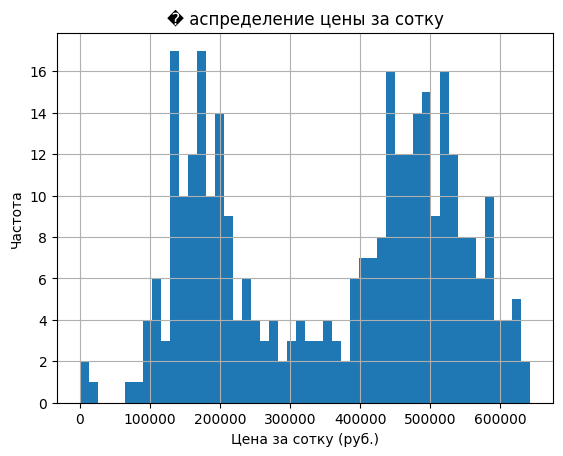

In [13]:
import numpy as np
import matplotlib.pyplot as plt
# 1) Цена за сотку (100 м²)
blocks_pred["land_value_per_100m2"] = blocks_pred["land_value"] / blocks_pred["site_area"] * 100

# 2) Заменяем inf на NaN
blocks_pred = blocks_pred.replace([np.inf, -np.inf], np.nan)
blocks_pred = blocks_pred.fillna(0)

# 3) Удаляем выбросы: оставляем данные до 99-го перцентиля
p99 = blocks_pred["land_value_per_100m2"].quantile(0.95)
blocks_clean = blocks_pred[blocks_pred["land_value_per_100m2"] <= p99].copy()

print(blocks_clean["land_value_per_100m2"].describe())

# 4) Гистограмма после очистки
plt.figure()
blocks_clean["land_value_per_100m2"].dropna().hist(bins=50)
plt.xlabel("Цена за сотку (руб.)")
plt.ylabel("Частота")
plt.title("� аспределение цены за сотку")
plt.show()



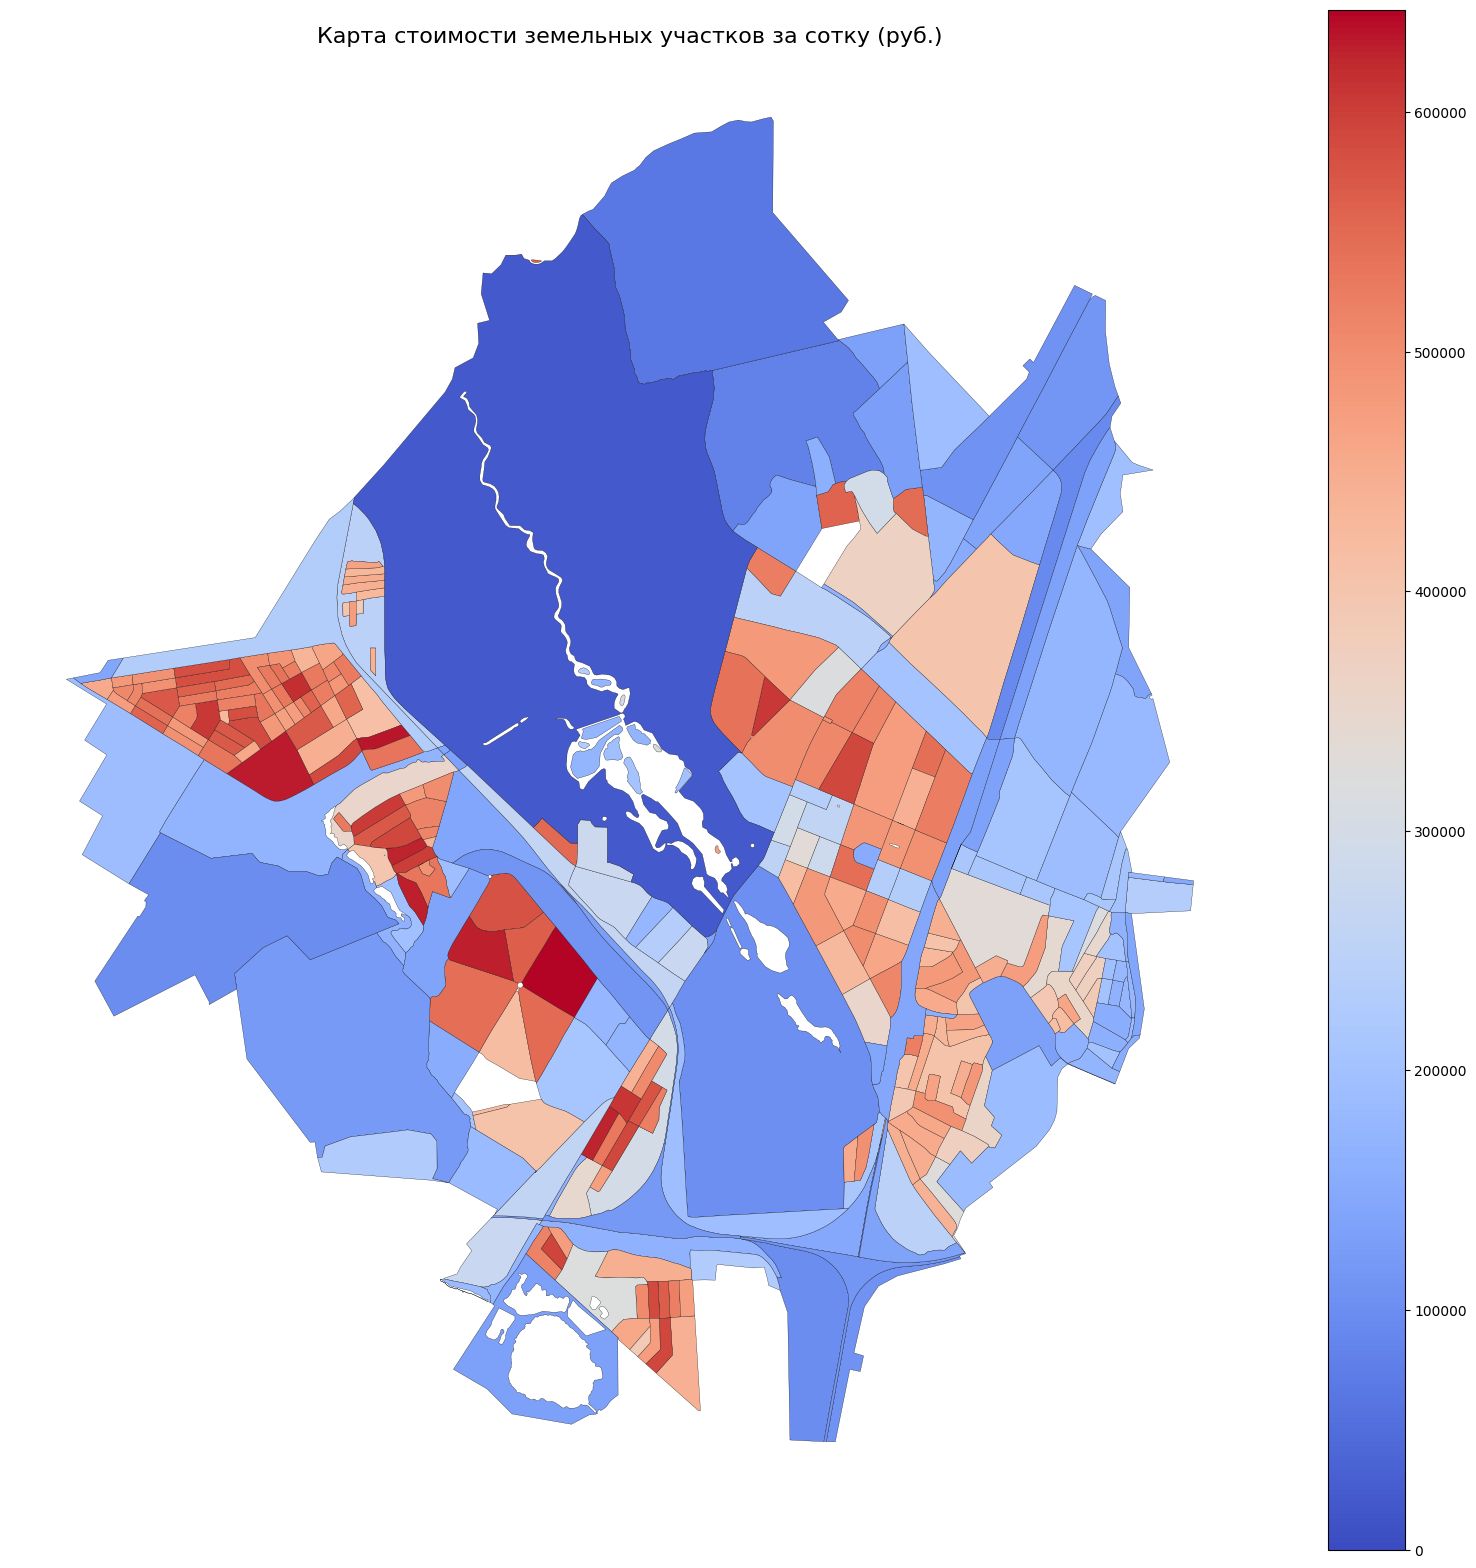

In [14]:
import matplotlib.pyplot as plt

blocks_clean.plot(
    column='land_value_per_100m2',
    legend=True,
    figsize=(20,20),
    cmap='coolwarm',
    edgecolor='black',   # <-- цвет границы
    linewidth=0.2        # <-- толщина границы
).set_axis_off()
plt.title('Карта стоимости земельных участков за сотку (руб.)', fontsize=16)

plt.show()

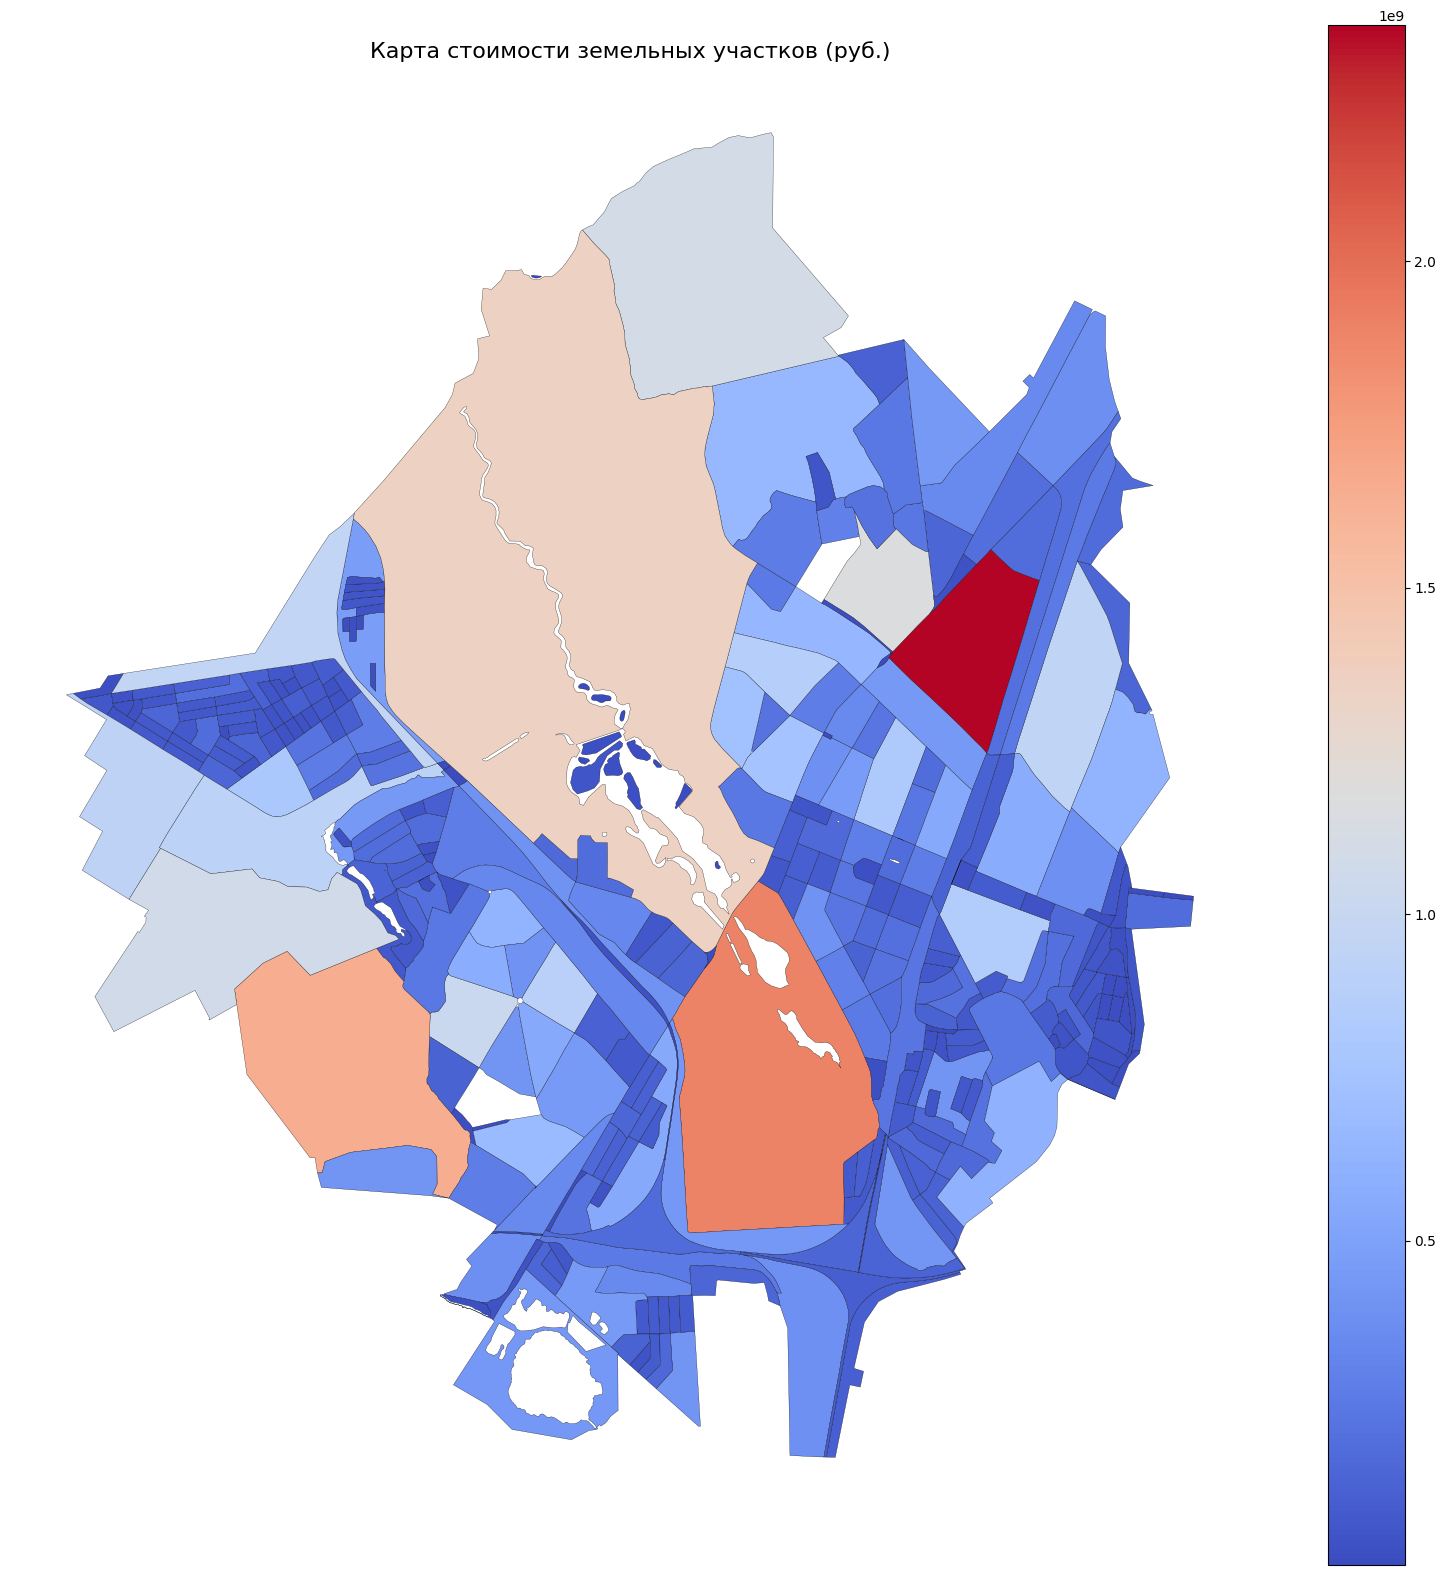

In [15]:
import matplotlib.pyplot as plt

blocks_clean.plot(
    column='land_value',
    legend=True,
    figsize=(20,20),
    cmap='coolwarm',
    edgecolor='black',   # <-- цвет границы
    linewidth=0.2        # <-- толщина границы
).set_axis_off()
plt.title('Карта стоимости земельных участков (руб.)', fontsize=16)

plt.show()

# Выбор сценария развития

In [16]:
blocks_clean["id"] = blocks_clean.index

In [17]:
target_id = 86

/var/folders/p2/g62_fg4547gdlj7_mqyl3nq80000gn/T/ipykernel_5520/4044864446.py:9: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  target_block.centroid.plot(ax=ax, color="red", markersize=30, zorder=3)


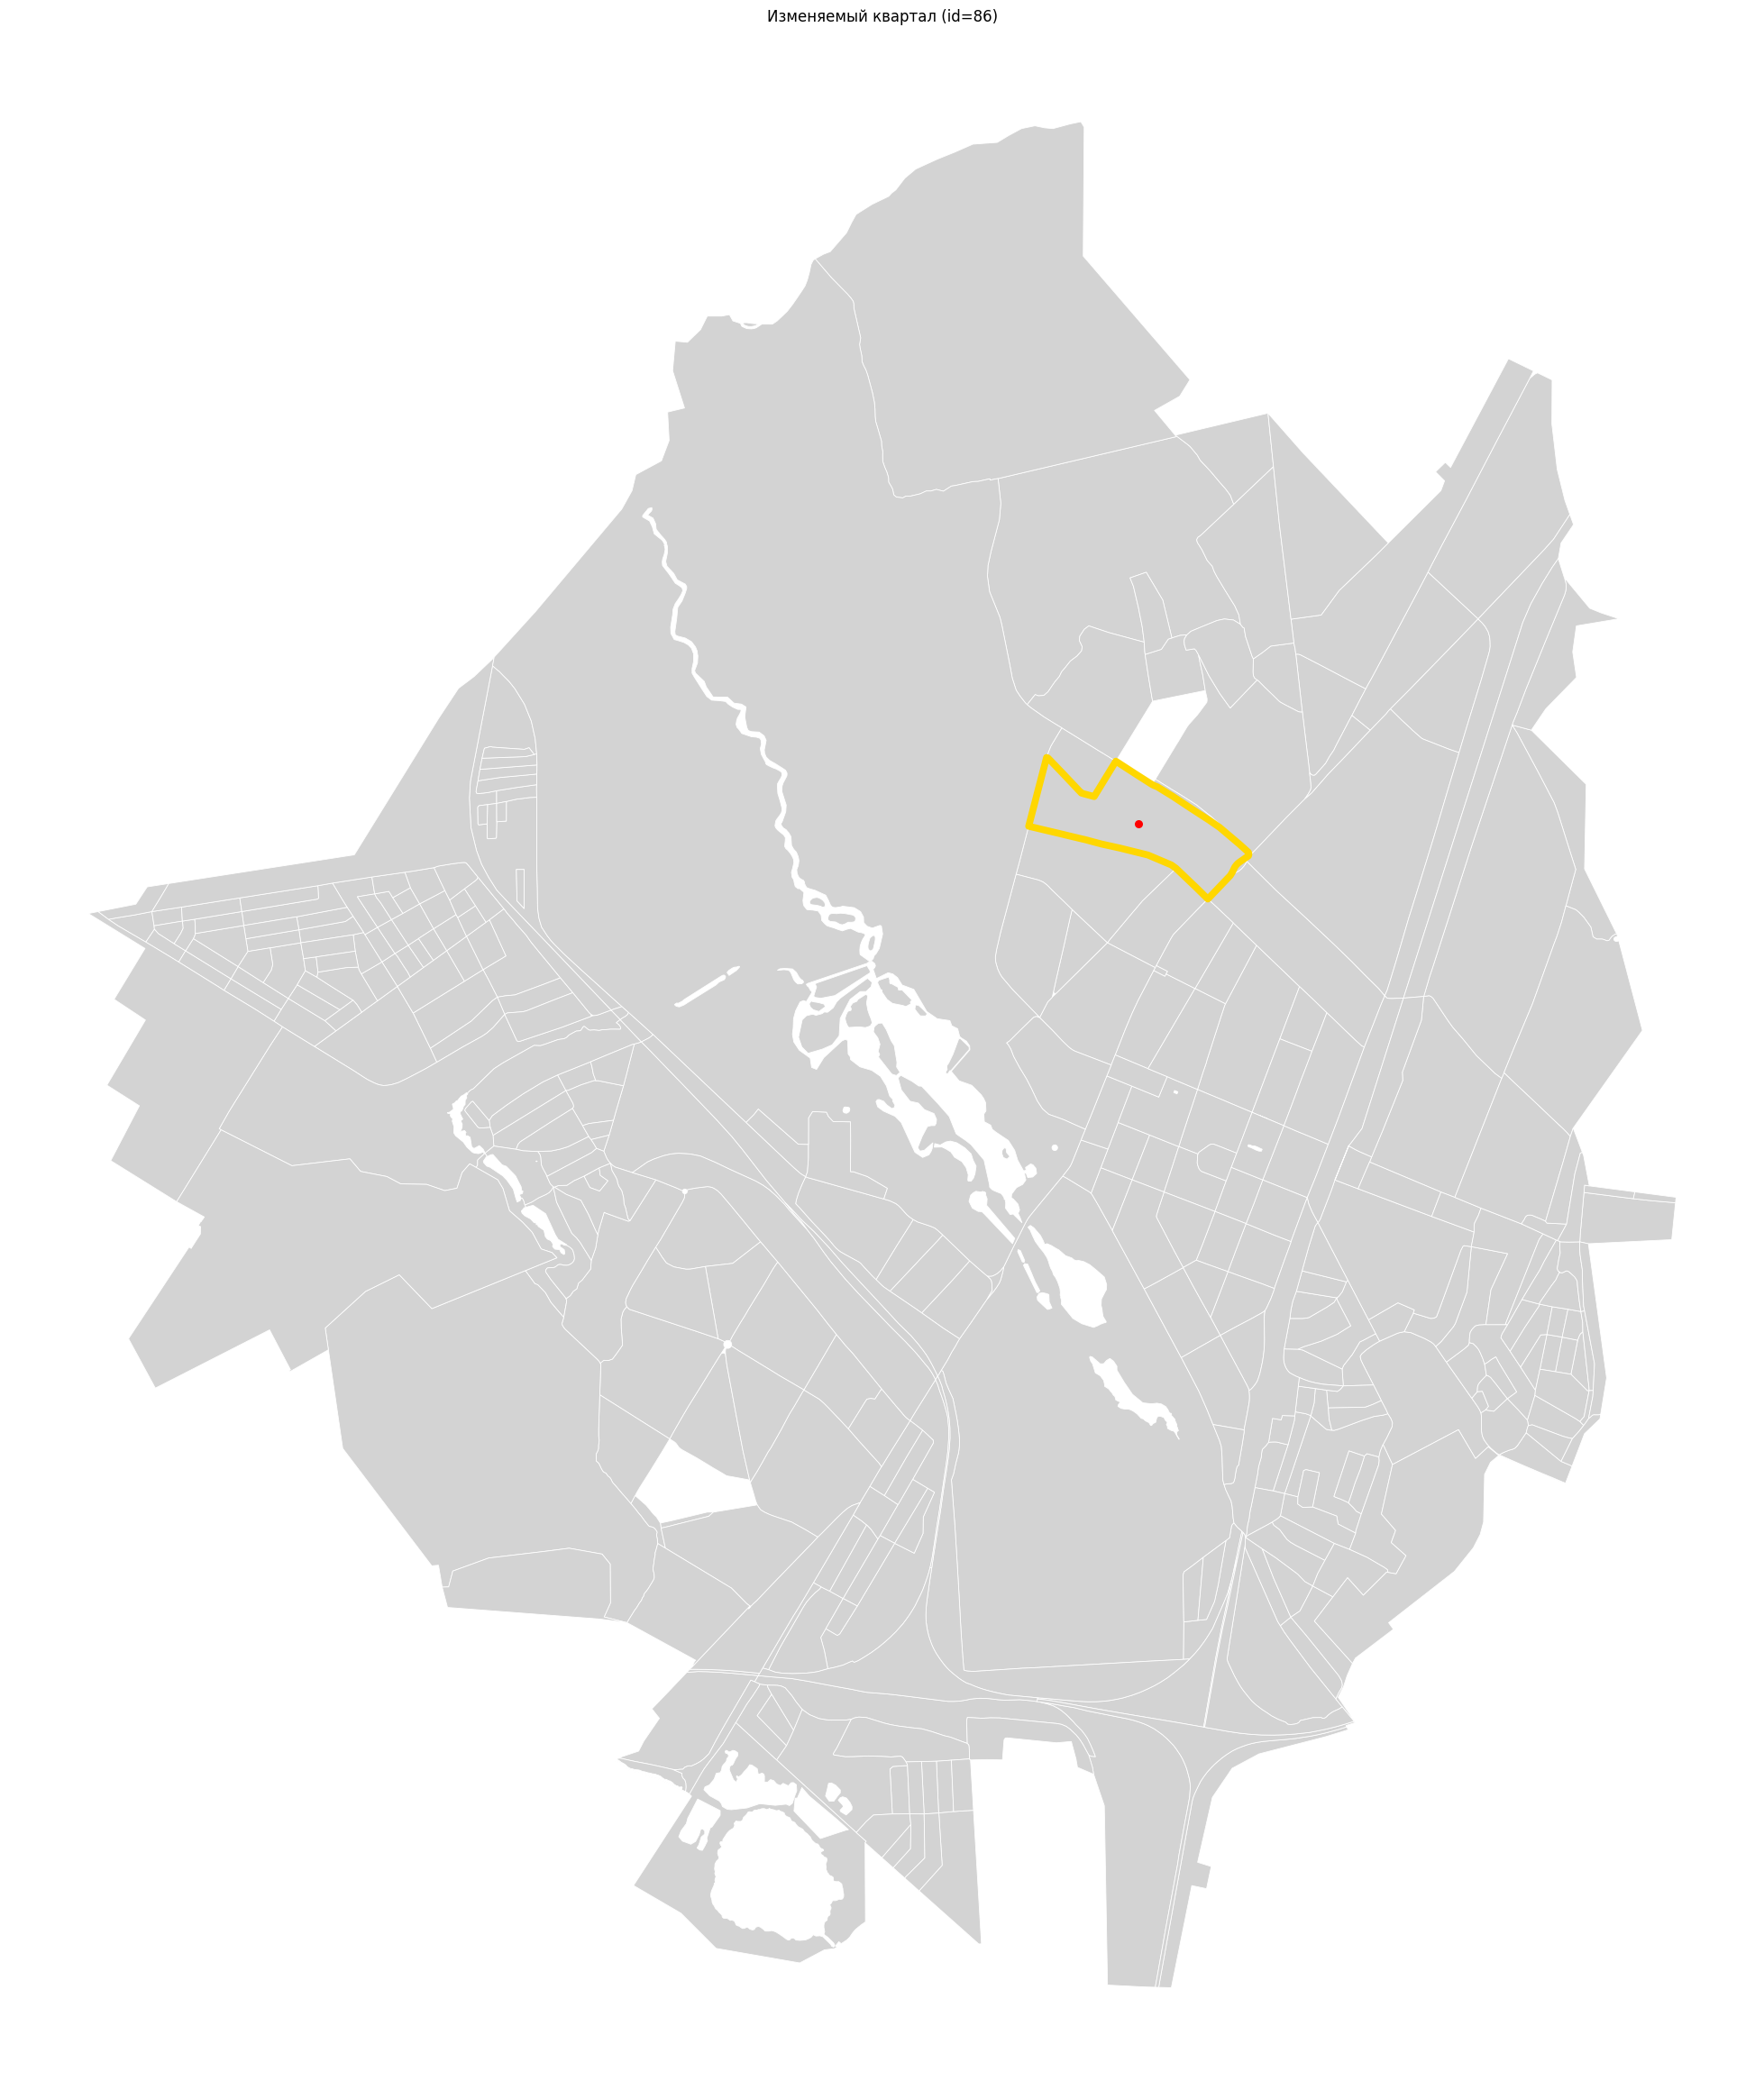

In [18]:
import matplotlib.pyplot as plt

target_id = 86
target_block = blocks_clean.loc[blocks_clean["id"] == target_id]

fig, ax = plt.subplots(figsize=(25, 35))
blocks_clean.plot(ax=ax, color="lightgrey", edgecolor="white", linewidth=0.6)
target_block.plot(ax=ax, color="none", edgecolor="gold", linewidth=5.5)
target_block.centroid.plot(ax=ax, color="red", markersize=30, zorder=3)

ax.set_title(f"Изменяемый квартал (id={target_id})")
ax.axis("off")
plt.show()


In [19]:
# blocks_after.to_file('./data/test/gatchina_RESIDENTIAL.geojson', driver='GeoJSON')

# Оптимизация района

## NSGA 2

In [20]:
site_area = float(blocks_clean.loc[blocks_clean["id"] == target_id, "site_area"].iloc[0])

constraints = {
    "footprint_area": {"type": "float", "min": 0.0, "max": 0.1 * site_area},
    "l": {"type": "float", "min": 1.0, "max": 10.0},
    "mxi": {"type": "float", "min": 0.1, "max": 1.0},

    "residential": {"type": "float", "min": 0.0, "max": 1.0},
    "business": {"type": "float", "min": 0.0, "max": 1.0},
    "recreation": {"type": "float", "min": 0.0, "max": 1.0},
    "industrial": {"type": "float", "min": 0.0, "max": 1.0},
    "transport": {"type": "float", "min": 0.0, "max": 1.0},
    "special": {"type": "float", "min": 0.0, "max": 1.0},
    "agriculture": {"type": "float", "min": 0.0, "max": 1.0},
}

from urbanomy.methods.land_value_modeling import (
    build_pareto_front_dataframe,
    run_nsga2_with_strategic_alignment,
)
from pathlib import Path
import pandas as pd

notebook_dir = Path("examples") if Path("examples/paper.ipynb").exists() else Path(".")
optimization_log_path = notebook_dir / "optimization_log.jsonl"
pareto_front_path = notebook_dir / "pareto_front.jsonl"

prompt = """
Evaluate the presented scenario based on the criterion of balancing the interests of various land users.
Analyze potential conflicts between residents, pedestrians, drivers, business owners, visitors, employees, seniors, and families with children.
Assign a score from 0 to 1.
Return only valid JSON without markdown, comments, or explanations, using this exact format:
{"score": 0.0}
""".strip()

res, problem = run_nsga2_with_strategic_alignment(
    blocks=blocks_clean,
    model=model,
    estimator_kwargs={
        "orig_features": numeric_feats + cat_features,
        "categorical_features": cat_features,
    },
    constraints=constraints,
    target_id=target_id,
    baseline=baseline,
    prompt=prompt,
    pop_size=20,
    n_gen=30,
    seed=42,
    verbose=True,
    save_history=True,
    log_optimization=True,
    optimization_log_path=optimization_log_path,
)

pareto_df = build_pareto_front_dataframe(res=res, problem=problem)
optimization_log_df = pd.DataFrame(problem.optimization_log)

pareto_df.to_json(pareto_front_path, orient="records", lines=True, force_ascii=False)


n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |       20 |      3 |             - |             -
     2 |       40 |      4 |  0.5000000000 |         ideal
     3 |       60 |      6 |  0.0344766839 |             f
     4 |       80 |      9 |  0.1703305043 |         ideal
     5 |      100 |      8 |  0.0233942571 |         ideal
     6 |      120 |     12 |  0.0165743766 |         ideal
     7 |      140 |     13 |  0.1521537326 |         ideal
     8 |      160 |     17 |  0.1372493790 |         ideal
     9 |      180 |     17 |  0.0198906570 |         ideal
    10 |      200 |     19 |  0.0029267798 |         ideal
    11 |      220 |     18 |  0.0909090909 |         ideal
    12 |      240 |     19 |  0.1196908404 |         ideal
    13 |      260 |     20 |  0.0833333333 |         ideal
    14 |      280 |     20 |  0.0184568693 |             f
    15 |      300 |     20 |  0.0718249438 |         ideal
    16 |      320 |     20 |  0.0242484085 |         ide

In [26]:
pareto_df

,scenario_id,title,summary,land_use,land_value_after,land_value_gain,investor_npv,params_repaired,llm score,ser_alignment_reasoning
0,scenario_0,scenario_0 | RECREATION,scenario_0 | RECREATION; land_use=RECREATION; ...,RECREATION,6.365899e+10,7.074730e+08,4.529726e+09,"{'footprint_area': 25378.02934831227, 'l': 9.9...",0.80,
1,scenario_1,scenario_1 | BUSINESS,scenario_1 | BUSINESS; land_use=BUSINESS; прир...,BUSINESS,6.309090e+10,1.393819e+08,6.605294e+09,"{'footprint_area': 25107.42816019796, 'l': 9.9...",0.25,
2,scenario_2,scenario_2 | BUSINESS,scenario_2 | BUSINESS; land_use=BUSINESS; прир...,BUSINESS,6.324475e+10,2.932260e+08,6.560384e+09,"{'footprint_area': 25382.398222395932, 'l': 9....",0.20,
3,scenario_3,scenario_3 | BUSINESS,scenario_3 | BUSINESS; land_use=BUSINESS; прир...,BUSINESS,6.152272e+10,-1.428804e+09,6.577734e+09,"{'footprint_area': 25382.398222395932, 'l': 9....",0.30,
4,scenario_4,scenario_4 | RECREATION,scenario_4 | RECREATION; land_use=RECREATION; ...,RECREATION,6.380302e+10,8.515026e+08,2.873385e+09,"{'footprint_area': 26066.144054081913, 'l': 9....",0.45,
5,scenario_5,scenario_5 | BUSINESS,scenario_5 | BUSINESS; land_use=BUSINESS; прир...,BUSINESS,6.246027e+10,-4.912495e+08,4.788286e+09,"{'footprint_area': 25170.82169952541, 'l': 9.9...",0.75,
6,scenario_6,scenario_6 | RECREATION,scenario_6 | RECREATION; land_use=RECREATION; ...,RECREATION,6.377729e+10,8.257695e+08,3.043913e+09,"{'footprint_area': 25378.932439220538, 'l': 9....",0.70,
7,scenario_7,scenario_7 | RECREATION,scenario_7 | RECREATION; land_use=RECREATION; ...,RECREATION,6.374831e+10,7.967879e+08,4.477773e+09,"{'footprint_area': 26066.144054081913, 'l': 9....",0.70,
8,scenario_8,scenario_8 | INDUSTRIAL,scenario_8 | INDUSTRIAL; land_use=INDUSTRIAL; ...,INDUSTRIAL,6.295636e+10,4.837149e+06,5.219043e+09,"{'footprint_area': 25350.799635637144, 'l': 9....",0.65,
9,scenario_9,scenario_9 | BUSINESS,scenario_9 | BUSINESS; land_use=BUSINESS; прир...,BUSINESS,6.271597e+10,-2.355464e+08,6.063743e+09,"{'footprint_area': 25380.87049152216, 'l': 9.8...",0.35,


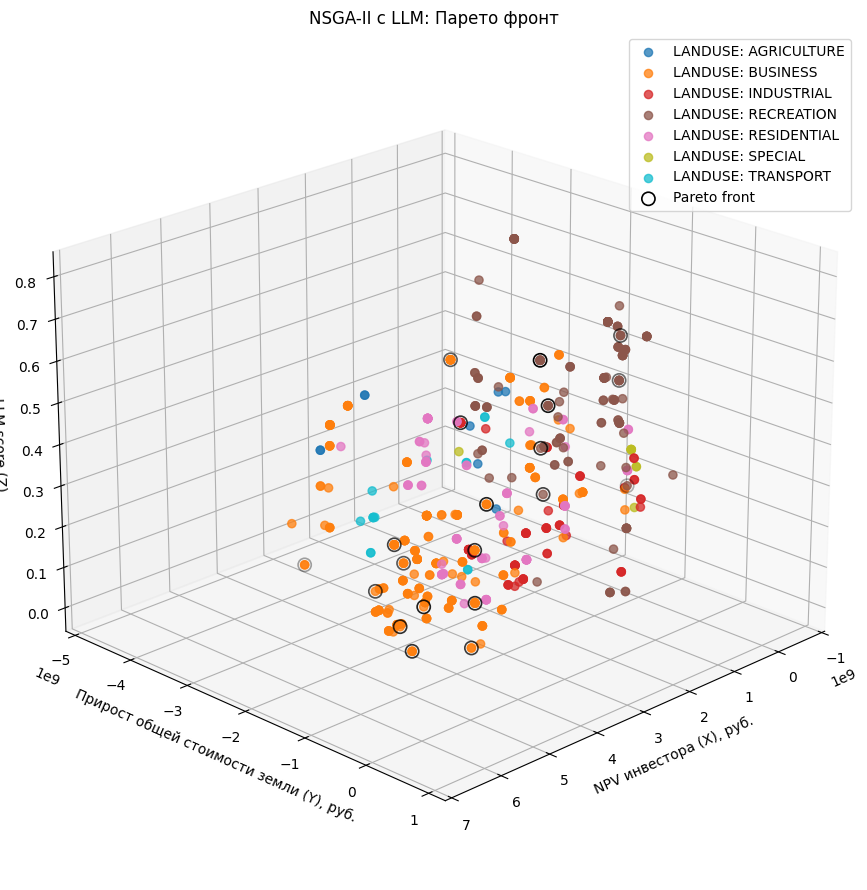

In [33]:
import numpy as np
import matplotlib.pyplot as plt

optimizer = problem
result = res

baseline_land_value = optimizer.evaluate_catboost(
    geonome=optimizer.blocks,
    model=optimizer.model,
    orig_features=optimizer.estimator_kwargs["orig_features"],
    cat_features=optimizer.estimator_kwargs["categorical_features"],
    radius_list=None,
)

X_all, F_all = [], []
if getattr(result, "history", None):
    for alg in result.history:
        pop = alg.pop
        Xi, Fi = pop.get("X"), pop.get("F")
        if Xi is not None and Fi is not None and len(Xi):
            X_all.append(np.asarray(Xi))
            F_all.append(np.asarray(Fi))

if X_all:
    X = np.vstack(X_all)
    F = np.vstack(F_all)
else:
    X = np.atleast_2d(np.asarray(result.X))
    F = np.atleast_2d(np.asarray(result.F))

land_value_total = -F[:, 0]
admin_gain = land_value_total - baseline_land_value
investor_npv = -F[:, 1]
llm_score = -F[:, 2]

landuse_labels = []
for genome_vec in X:
    changes = {name: genome_vec[j] for j, name in enumerate(optimizer.var_names)}
    repaired = optimizer._repair_genome(changes)
    lu = repaired["land_use"]
    landuse_labels.append(getattr(lu, "name", str(lu).split(".")[-1]))

landuse_labels = np.asarray(landuse_labels)
unique_lu = np.unique(landuse_labels)

cmap = plt.get_cmap("tab10", len(unique_lu))
color_map = {lu: cmap(i) for i, lu in enumerate(unique_lu)}

fig = plt.figure(figsize=(11, 9))
ax = fig.add_subplot(111, projection="3d")

for lu in unique_lu:
    m = landuse_labels == lu
    ax.scatter(
        investor_npv[m],
        admin_gain[m],
        llm_score[m],
        s=35,
        alpha=0.75,
        color=color_map[lu],
        label=f"LANDUSE: {lu}",
    )

F_front = np.atleast_2d(np.asarray(result.F))
pf_x = -F_front[:, 1]
pf_y = -F_front[:, 0] - baseline_land_value
pf_z = -F_front[:, 2]

ax.scatter(
    pf_x,
    pf_y,
    pf_z,
    s=90,
    c="none",
    edgecolors="black",
    linewidths=1.2,
    label="Pareto front",
)

ax.set_xlabel("NPV инвестора (X), руб.")
ax.set_ylabel("Прирост общей стоимости земли (Y), руб.")
ax.set_zlabel("LLM score (Z)")
ax.set_title("NSGA-II с LLM: Парето фронт")
ax.view_init(elev=22, azim=45)
ax.legend(loc="best")
plt.tight_layout()
plt.show()


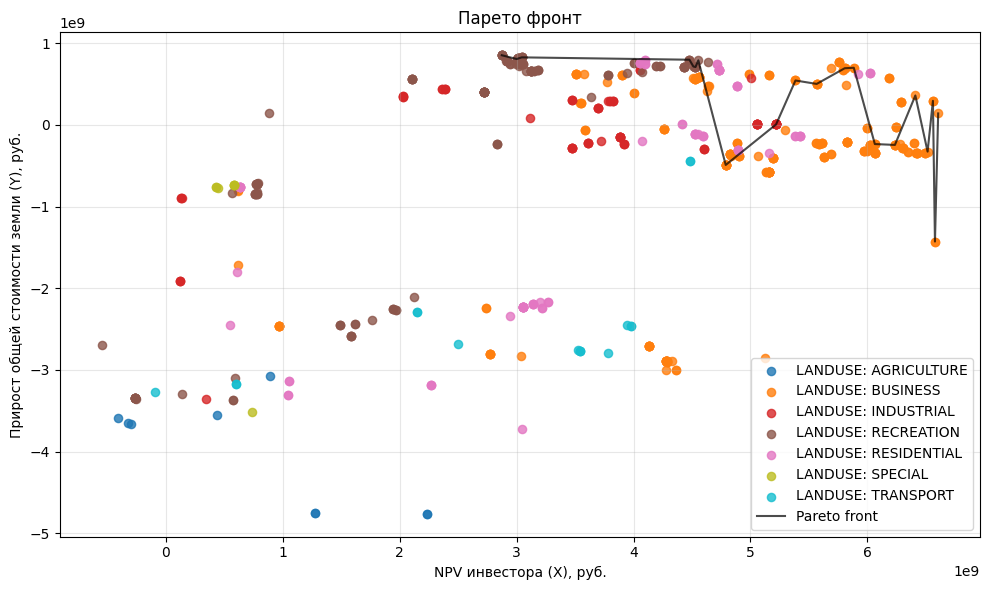

In [43]:
import numpy as np
import matplotlib.pyplot as plt

optimizer = problem

# 1) Базовая стоимость "до"
baseline_land_value = optimizer.evaluate_catboost(
    geonome=optimizer.blocks,
    model=optimizer.model,
    orig_features=optimizer.estimator_kwargs["orig_features"],
    cat_features=optimizer.estimator_kwargs["categorical_features"],
    radius_list=None,
)

# 2) Собираем ВСЕ решения: из history (если optimize(..., save_history=True)), иначе из res.X/res.F
X_all, F_all = [], []
if getattr(res, "history", None):
    for alg in res.history:
        pop = alg.pop
        Xi, Fi = pop.get("X"), pop.get("F")
        if Xi is not None and Fi is not None and len(Xi):
            X_all.append(np.asarray(Xi))
            F_all.append(np.asarray(Fi))

if X_all:
    X = np.vstack(X_all)
    F = np.vstack(F_all)
else:
    X = np.asarray(res.X)
    F = np.asarray(res.F)

# 3) Цели
land_value_total = -F[:, 0]
admin_gain = land_value_total - baseline_land_value
investor_npv = -F[:, 1]

# 4) LANDUSE для каждого решения (через тот же repair, что в оптимизаторе)
landuse_labels = []
for genome_vec in X:
    changes = {name: genome_vec[j] for j, name in enumerate(optimizer.var_names)}
    repaired = optimizer._repair_genome(changes)   # использует логику из вашей задачи
    lu = repaired["land_use"]
    lu_name = getattr(lu, "name", str(lu).split(".")[-1])
    landuse_labels.append(lu_name)

landuse_labels = np.array(landuse_labels)
unique_lu = np.unique(landuse_labels)

# 5) Цвета + легенда
cmap = plt.get_cmap("tab10", len(unique_lu))
color_map = {lu: cmap(i) for i, lu in enumerate(unique_lu)}

plt.figure(figsize=(10, 6))

for lu in unique_lu:
    m = landuse_labels == lu
    plt.scatter(
        investor_npv[m],
        admin_gain[m],
        s=35,
        alpha=0.8,
        color=color_map[lu],
        label=f"LANDUSE: {lu}",
    )

# (опционально) поверх — линия самого Pareto-фронта из res.F
pf_x = -res.F[:, 1]
pf_y = -res.F[:, 0] - baseline_land_value
order = np.argsort(pf_x)
plt.plot(pf_x[order], pf_y[order], color="black", lw=1.5, alpha=0.7, label="Pareto front")

plt.xlabel("NPV инвестора (X), руб.")
plt.ylabel("Прирост общей стоимости земли (Y), руб.")
plt.title("Парето фронт")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()   

## NSGA II (без LLM)

In [27]:
from pathlib import Path

import pandas as pd
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize

from urbanomy.methods.land_value_modeling import DistrictProblem, build_pareto_front_dataframe

notebook_dir = Path("examples") if Path("examples/paper.ipynb").exists() else Path(".")

problem_no_llm = DistrictProblem(
    blocks=blocks_clean,
    model=model,
    estimator_kwargs={
        "orig_features": numeric_feats + cat_features,
        "categorical_features": cat_features,
    },
    constraints=constraints,
    target_id=target_id,
    log_optimization=True,
)

algorithm = NSGA2(
    pop_size=20,
    eliminate_duplicates=True,
)

res_no_llm = minimize(
    problem_no_llm,
    algorithm,
    ('n_gen', 30),
    seed=42,
    verbose=True,
    save_history=True,
)

no_llm_log_df = pd.DataFrame(problem_no_llm.optimization_log)
no_llm_pareto_df = build_pareto_front_dataframe(
    res=res_no_llm,
    problem=problem_no_llm,
    scenario_prefix="no_llm_pareto",
)

no_llm_log_df.to_json(notebook_dir / "no_llm_optimization_log.jsonl", orient="records", lines=True, force_ascii=False)
no_llm_pareto_df.to_json(notebook_dir / "no_llm_pareto_front.jsonl", orient="records", lines=True, force_ascii=False)


n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |       20 |      3 |             - |             -
     2 |       40 |      3 |  0.2693558020 |         ideal
     3 |       60 |      7 |  0.0420502881 |             f
     4 |       80 |      4 |  0.1249173303 |         ideal
     5 |      100 |      1 |  1.295196E+09 |         ideal
     6 |      120 |      1 |  0.000000E+00 |             f
     7 |      140 |      3 |  0.0529380380 |         ideal
     8 |      160 |      5 |  0.1529471465 |         ideal
     9 |      180 |      7 |  0.0209121068 |         ideal
    10 |      200 |      5 |  0.0236623998 |         ideal
    11 |      220 |      5 |  0.1110914762 |         ideal
    12 |      240 |      5 |  0.3664375939 |         ideal
    13 |      260 |      5 |  0.0153815063 |         ideal
    14 |      280 |      6 |  0.2071398715 |         ideal
    15 |      300 |      7 |  0.0404138774 |             f
    16 |      320 |      8 |  0.0729903187 |         ide

In [29]:
no_llm_pareto_df

,scenario_id,title,summary,land_use,land_value_after,land_value_gain,investor_npv,params_repaired
0,no_llm_pareto_0,no_llm_pareto_0 | RESIDENTIAL,no_llm_pareto_0 | RESIDENTIAL; land_use=RESIDE...,RESIDENTIAL,6.376520e+10,8.136849e+08,5.379493e+09,"{'footprint_area': 26206.04138363824, 'l': 9.7..."
1,no_llm_pareto_1,no_llm_pareto_1 | RESIDENTIAL,no_llm_pareto_1 | RESIDENTIAL; land_use=RESIDE...,RESIDENTIAL,6.376989e+10,8.183662e+08,5.267828e+09,"{'footprint_area': 25983.386274268985, 'l': 9...."
2,no_llm_pareto_2,no_llm_pareto_2 | RESIDENTIAL,no_llm_pareto_2 | RESIDENTIAL; land_use=RESIDE...,RESIDENTIAL,6.377051e+10,8.189894e+08,5.254137e+09,"{'footprint_area': 25992.44655616865, 'l': 9.7..."
3,no_llm_pareto_3,no_llm_pareto_3 | RESIDENTIAL,no_llm_pareto_3 | RESIDENTIAL; land_use=RESIDE...,RESIDENTIAL,6.376865e+10,8.171272e+08,5.273577e+09,"{'footprint_area': 25983.945558165888, 'l': 9...."
4,no_llm_pareto_4,no_llm_pareto_4 | RESIDENTIAL,no_llm_pareto_4 | RESIDENTIAL; land_use=RESIDE...,RESIDENTIAL,6.377048e+10,8.189627e+08,5.255993e+09,"{'footprint_area': 25993.89102608368, 'l': 9.7..."
5,no_llm_pareto_5,no_llm_pareto_5 | RESIDENTIAL,no_llm_pareto_5 | RESIDENTIAL; land_use=RESIDE...,RESIDENTIAL,6.375361e+10,8.020900e+08,5.883588e+09,"{'footprint_area': 25992.44655616865, 'l': 9.7..."
6,no_llm_pareto_6,no_llm_pareto_6 | RESIDENTIAL,no_llm_pareto_6 | RESIDENTIAL; land_use=RESIDE...,RESIDENTIAL,6.376243e+10,8.109121e+08,5.669333e+09,"{'footprint_area': 25775.770459970172, 'l': 9...."
7,no_llm_pareto_7,no_llm_pareto_7 | RESIDENTIAL,no_llm_pareto_7 | RESIDENTIAL; land_use=RESIDE...,RESIDENTIAL,6.358565e+10,6.341305e+08,7.124330e+09,"{'footprint_area': 25983.681769308932, 'l': 9...."
8,no_llm_pareto_8,no_llm_pareto_8 | RESIDENTIAL,no_llm_pareto_8 | RESIDENTIAL; land_use=RESIDE...,RESIDENTIAL,6.376791e+10,8.163913e+08,5.377099e+09,"{'footprint_area': 26219.501791226525, 'l': 9...."
9,no_llm_pareto_9,no_llm_pareto_9 | RESIDENTIAL,no_llm_pareto_9 | RESIDENTIAL; land_use=RESIDE...,RESIDENTIAL,6.371858e+10,7.670559e+08,7.036368e+09,"{'footprint_area': 25971.54551142473, 'l': 9.7..."


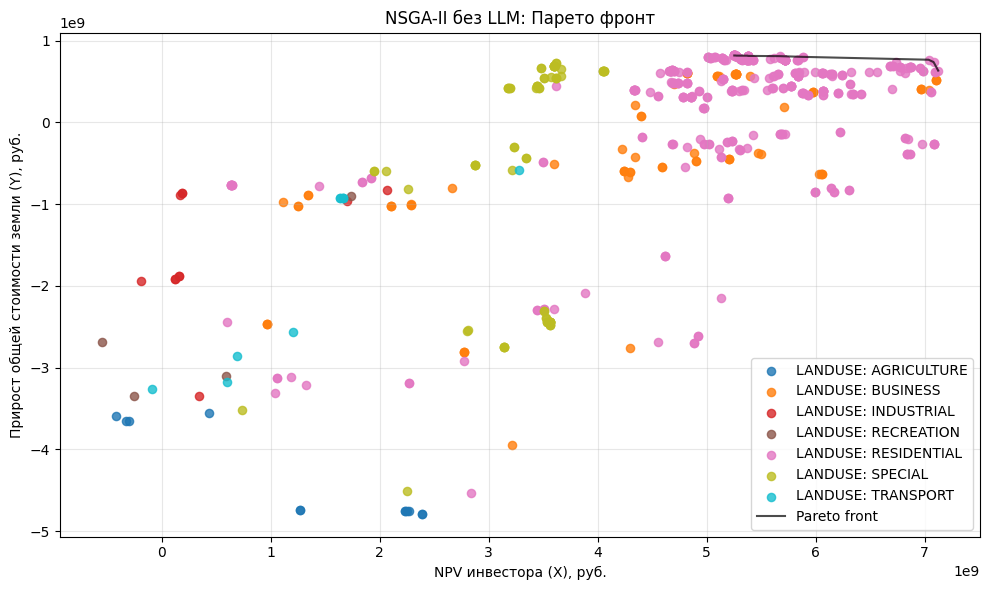

In [32]:
import numpy as np
import matplotlib.pyplot as plt

optimizer = problem_no_llm
result = res_no_llm

baseline_land_value = optimizer.evaluate_catboost(
    geonome=optimizer.blocks,
    model=optimizer.model,
    orig_features=optimizer.estimator_kwargs["orig_features"],
    cat_features=optimizer.estimator_kwargs["categorical_features"],
    radius_list=None,
)

X_all, F_all = [], []
if getattr(result, "history", None):
    for alg in result.history:
        pop = alg.pop
        Xi, Fi = pop.get("X"), pop.get("F")
        if Xi is not None and Fi is not None and len(Xi):
            X_all.append(np.asarray(Xi))
            F_all.append(np.asarray(Fi))

if X_all:
    X = np.vstack(X_all)
    F = np.vstack(F_all)
else:
    X = np.atleast_2d(np.asarray(result.X))
    F = np.atleast_2d(np.asarray(result.F))

land_value_total = -F[:, 0]
admin_gain = land_value_total - baseline_land_value
investor_npv = -F[:, 1]

landuse_labels = []
for genome_vec in X:
    changes = {name: genome_vec[j] for j, name in enumerate(optimizer.var_names)}
    repaired = optimizer._repair_genome(changes)
    lu = repaired["land_use"]
    landuse_labels.append(getattr(lu, "name", str(lu).split(".")[-1]))

landuse_labels = np.asarray(landuse_labels)
unique_lu = np.unique(landuse_labels)

cmap = plt.get_cmap("tab10", len(unique_lu))
color_map = {lu: cmap(i) for i, lu in enumerate(unique_lu)}

plt.figure(figsize=(10, 6))
for lu in unique_lu:
    m = landuse_labels == lu
    plt.scatter(
        investor_npv[m],
        admin_gain[m],
        s=35,
        alpha=0.8,
        color=color_map[lu],
        label=f"LANDUSE: {lu}",
    )

F_front = np.atleast_2d(np.asarray(result.F))
pf_x = -F_front[:, 1]
pf_y = -F_front[:, 0] - baseline_land_value
order = np.argsort(pf_x)
plt.plot(pf_x[order], pf_y[order], color="black", lw=1.5, alpha=0.7, label="Pareto front")

plt.xlabel("NPV инвестора (X), руб.")
plt.ylabel("Прирост общей стоимости земли (Y), руб.")
plt.title("NSGA-II без LLM: Парето фронт")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# Сравнение парето фронтов

,algorithm,n_solutions,hypervolume_2d,hypervolume_2d_norm,min_investor_npv,max_investor_npv,min_land_value_gain,max_land_value_gain
0,NSGA-II + LLM,20,4.128455e+19,0.917544,2.873385e+09,6.605294e+09,-1.428804e+09,8.515026e+08
1,NSGA-II без LLM,11,4.466752e+19,0.992730,5.254137e+09,7.124330e+09,6.341305e+08,8.189894e+08


Reference point: NPV=-548,793,299; прирост стоимости=-5,012,421,050


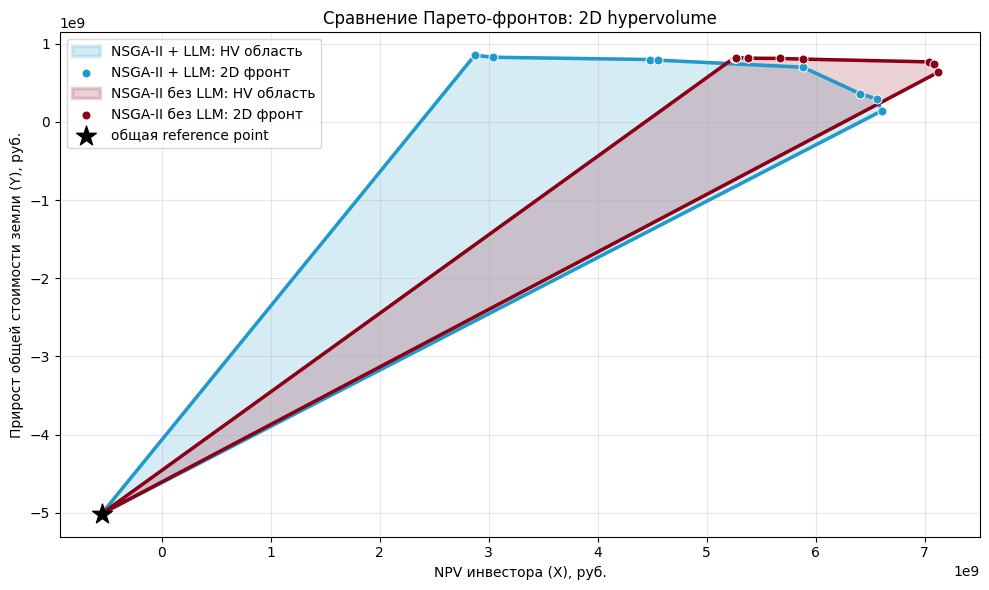

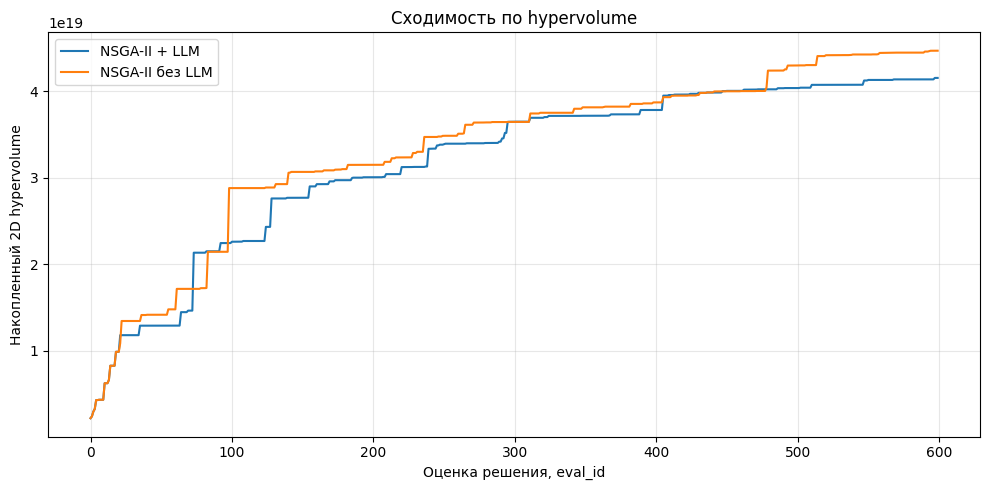

algorithm,NSGA-II + LLM,NSGA-II без LLM
land_use,,
BUSINESS,12,0
INDUSTRIAL,1,0
RECREATION,7,0
RESIDENTIAL,0,11


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

notebook_dir = Path("examples") if Path("examples/paper.ipynb").exists() else Path(".")
pareto_front_path = notebook_dir / "pareto_front.jsonl"
no_llm_pareto_front_path = notebook_dir / "no_llm_pareto_front.jsonl"

llm_front = pd.read_json(pareto_front_path, lines=True)
no_llm_front = pd.read_json(no_llm_pareto_front_path, lines=True)


def front_xy(df, label):
    out = df[["investor_npv", "land_value_gain", "land_use"]].copy()
    out["algorithm"] = label
    out["investor_npv"] = pd.to_numeric(out["investor_npv"], errors="coerce")
    out["land_value_gain"] = pd.to_numeric(out["land_value_gain"], errors="coerce")
    return out.dropna(subset=["investor_npv", "land_value_gain"])


fronts = pd.concat(
    [front_xy(llm_front, "NSGA-II + LLM"), front_xy(no_llm_front, "NSGA-II без LLM")],
    ignore_index=True,
)

def all_solutions_xy(path):
    df = pd.read_json(path, lines=True)
    out = df[["investor_npv", "land_value_gain"]].copy()
    out["investor_npv"] = pd.to_numeric(out["investor_npv"], errors="coerce")
    out["land_value_gain"] = pd.to_numeric(out["land_value_gain"], errors="coerce")
    return out.dropna(subset=["investor_npv", "land_value_gain"])


all_solutions = pd.concat(
    [
        all_solutions_xy(notebook_dir / "optimization_log.jsonl"),
        all_solutions_xy(notebook_dir / "no_llm_optimization_log.jsonl"),
    ],
    ignore_index=True,
)

points_all = all_solutions[["investor_npv", "land_value_gain"]].to_numpy(float)
reference_point = points_all.min(axis=0)


def nondominated_2d(points):
    points = np.asarray(points, dtype=float)
    points = points[np.isfinite(points).all(axis=1)]
    keep = []
    for i, p in enumerate(points):
        others = np.delete(points, i, axis=0)
        dominated = np.any(
            (others[:, 0] >= p[0])
            & (others[:, 1] >= p[1])
            & ((others[:, 0] > p[0]) | (others[:, 1] > p[1]))
        )
        if not dominated:
            keep.append(p)
    return np.array(sorted(keep, key=lambda p: p[0]))


def hypervolume_2d(points, reference):
    front = nondominated_2d(points)
    hv = 0.0
    prev_x = reference[0]
    for x, y in front:
        hv += max(0.0, x - prev_x) * max(0.0, y - reference[1])
        prev_x = max(prev_x, x)
    return hv, front


def front_polygon_2d(front, reference):
    front = np.asarray(front, dtype=float)
    if len(front) == 0:
        return np.empty((0, 2))

    if np.linalg.norm(front[-1] - reference) < np.linalg.norm(front[0] - reference):
        front = front[::-1]

    polygon = np.vstack([reference, front, reference])
    return np.asarray(polygon)


rows = []
front_lines = {}
for algorithm, df in fronts.groupby("algorithm"):
    points = df[["investor_npv", "land_value_gain"]].to_numpy(float)
    hv, line = hypervolume_2d(points, reference_point)
    front_lines[algorithm] = line
    rows.append(
        {
            "algorithm": algorithm,
            "n_solutions": len(df),
            "hypervolume_2d": hv,
            "hypervolume_2d_norm": hv
            / np.prod(points_all.max(axis=0) - reference_point),
            "min_investor_npv": df["investor_npv"].min(),
            "max_investor_npv": df["investor_npv"].max(),
            "min_land_value_gain": df["land_value_gain"].min(),
            "max_land_value_gain": df["land_value_gain"].max(),
        }
    )

comparison_metrics = pd.DataFrame(rows).sort_values("algorithm")
display(comparison_metrics)
print(
    "Reference point:",
    f"NPV={reference_point[0]:,.0f}; прирост стоимости={reference_point[1]:,.0f}",
)

def plot_front_comparison():
    colors = {"NSGA-II + LLM": "#1f9acb", "NSGA-II без LLM": "#8b0015"}
    plt.figure(figsize=(10, 6))

    for algorithm, line in front_lines.items():
        color = colors.get(algorithm)
        polygon = front_polygon_2d(line, reference_point)
        plt.fill(
            polygon[:, 0],
            polygon[:, 1],
            facecolor=color,
            edgecolor=color,
            linewidth=2.5,
            alpha=0.18,
            label=f"{algorithm}: HV область",
        )
        plt.plot(polygon[:, 0], polygon[:, 1], color=color, lw=2.5)
        plt.scatter(
            line[:, 0],
            line[:, 1],
            s=42,
            color=color,
            edgecolor="white",
            linewidth=0.7,
            zorder=4,
            label=f"{algorithm}: 2D фронт",
        )

    plt.scatter(
        reference_point[0],
        reference_point[1],
        marker="*",
        s=220,
        c="black",
        label="общая reference point",
        zorder=5,
    )
    plt.xlabel("NPV инвестора (X), руб.")
    plt.ylabel("Прирост общей стоимости земли (Y), руб.")
    plt.title("Сравнение Парето-фронтов: 2D hypervolume")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_front_comparison()


def running_hv(log_path):
    df = pd.read_json(log_path, lines=True)
    df = df.dropna(subset=["investor_npv", "land_value_gain"]).sort_values("eval_id")
    values = []
    seen = []
    for _, row in df.iterrows():
        seen.append([row["investor_npv"], row["land_value_gain"]])
        hv, _ = hypervolume_2d(seen, reference_point)
        values.append({"eval_id": row["eval_id"], "hypervolume_2d": hv})
    return pd.DataFrame(values)


running = {
    "NSGA-II + LLM": running_hv(notebook_dir / "optimization_log.jsonl"),
    "NSGA-II без LLM": running_hv(notebook_dir / "no_llm_optimization_log.jsonl"),
}

plt.figure(figsize=(10, 5))
for algorithm, df in running.items():
    plt.plot(df["eval_id"], df["hypervolume_2d"], label=algorithm)
plt.xlabel("Оценка решения, eval_id")
plt.ylabel("Накопленный 2D hypervolume")
plt.title("Сходимость по hypervolume")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

land_use_diversity = pd.crosstab(fronts["land_use"], fronts["algorithm"])
display(land_use_diversity)


In [50]:
from pathlib import Path

import pandas as pd

from urbanomy.methods.land_value_modeling import StrategicAlignmentScorer

notebook_dir = Path("examples") if Path("examples/paper.ipynb").exists() else Path(".")
no_llm_pareto_path = notebook_dir / "no_llm_pareto_front.jsonl"
no_llm_pareto_scored_path = notebook_dir / "no_llm_pareto_front_scored.jsonl"

no_llm_pareto_scored_df = (
    pd.read_json(no_llm_pareto_scored_path, lines=True)
    if no_llm_pareto_scored_path.exists()
    else pd.read_json(no_llm_pareto_path, lines=True)
)

if "llm score" not in no_llm_pareto_scored_df.columns:
    no_llm_pareto_scored_df["llm score"] = pd.NA
if "ser_alignment_reasoning" not in no_llm_pareto_scored_df.columns:
    no_llm_pareto_scored_df["ser_alignment_reasoning"] = ""

scorer = problem.strategic_alignment_scorer if "problem" in globals() else None
if scorer is None:
    scorer = StrategicAlignmentScorer(llm=llm, prompt=prompt, max_retries=2)

missing_score = no_llm_pareto_scored_df["llm score"].isna()
for idx, row in no_llm_pareto_scored_df.loc[missing_score].iterrows():
    scored = scorer.score_candidate(
        params_repaired=row["params_repaired"],
        land_value_gain=row["land_value_gain"],
        investor_npv=row["investor_npv"],
    )
    no_llm_pareto_scored_df.at[idx, "llm score"] = scored["score"]
    no_llm_pareto_scored_df.at[idx, "ser_alignment_reasoning"] = scored.get("reasoning", "")

no_llm_pareto_scored_df.to_json(
    no_llm_pareto_scored_path,
    orient="records",
    lines=True,
    force_ascii=False,
)

no_llm_pareto_scored_df[["scenario_id", "land_use", "land_value_gain", "investor_npv", "llm score"]]


,scenario_id,land_use,land_value_gain,investor_npv,llm score
0,no_llm_pareto_0,RESIDENTIAL,8.136849e+08,5.379493e+09,0.4
1,no_llm_pareto_1,RESIDENTIAL,8.183662e+08,5.267828e+09,0.3
2,no_llm_pareto_2,RESIDENTIAL,8.189894e+08,5.254137e+09,0.4
3,no_llm_pareto_3,RESIDENTIAL,8.171272e+08,5.273577e+09,0.35
4,no_llm_pareto_4,RESIDENTIAL,8.189627e+08,5.255993e+09,0.3
5,no_llm_pareto_5,RESIDENTIAL,8.020900e+08,5.883588e+09,0.4
6,no_llm_pareto_6,RESIDENTIAL,8.109121e+08,5.669333e+09,0.3
7,no_llm_pareto_7,RESIDENTIAL,6.341305e+08,7.124330e+09,0.25
8,no_llm_pareto_8,RESIDENTIAL,8.163913e+08,5.377099e+09,0.35
9,no_llm_pareto_9,RESIDENTIAL,7.670559e+08,7.036368e+09,0.2


,metric,algorithm,n_solutions,n_2d_front,hypervolume,hypervolume_norm
0,LLM score × прирост стоимости земли,NSGA-II + LLM,20,3,1.393869e+09,0.992150
1,LLM score × прирост стоимости земли,NSGA-II без LLM,11,1,4.768252e+08,0.339402
2,LLM score × NPV инвестора,NSGA-II + LLM,20,7,1.648540e+09,0.629452
3,LLM score × NPV инвестора,NSGA-II без LLM,11,2,8.953213e+08,0.341855
4,3D: LLM score × прирост земли × NPV,NSGA-II + LLM,20,20,3.399625e+18,0.563611
5,3D: LLM score × прирост земли × NPV,NSGA-II без LLM,11,11,2.010812e+18,0.333365


,metric,better_algorithm,better_by_pct,best_hypervolume,other_hypervolume
0,3D: LLM score × прирост земли × NPV,NSGA-II + LLM,69.067290,3.399625e+18,2.010812e+18
1,LLM score × NPV инвестора,NSGA-II + LLM,84.128311,1.648540e+09,8.953213e+08
2,LLM score × прирост стоимости земли,NSGA-II + LLM,192.322821,1.393869e+09,4.768252e+08


3D: LLM score × прирост земли × NPV: лучше NSGA-II + LLM на 69.1% по hypervolume.
LLM score × NPV инвестора: лучше NSGA-II + LLM на 84.1% по hypervolume.
LLM score × прирост стоимости земли: лучше NSGA-II + LLM на 192.3% по hypervolume.


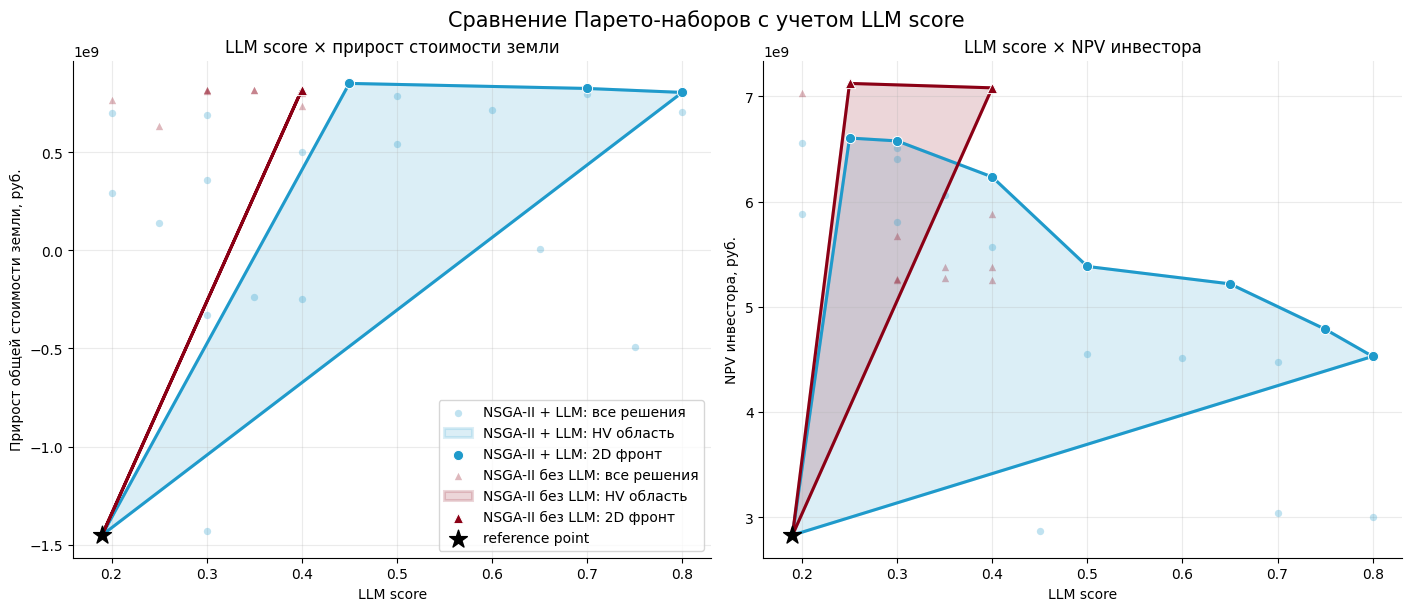

In [55]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

notebook_dir = Path("examples") if Path("examples/paper.ipynb").exists() else Path(".")

llm_3d = pareto_df.copy() if "pareto_df" in globals() else pd.read_json(notebook_dir / "pareto_front.jsonl", lines=True)
no_llm_3d = no_llm_pareto_scored_df.copy() if "no_llm_pareto_scored_df" in globals() else pd.read_json(notebook_dir / "no_llm_pareto_front_scored.jsonl", lines=True)

llm_3d["algorithm"] = "NSGA-II + LLM"
no_llm_3d["algorithm"] = "NSGA-II без LLM"

for df in (llm_3d, no_llm_3d):
    df["llm_score"] = pd.to_numeric(df.get("llm score"), errors="coerce")
    df["investor_npv"] = pd.to_numeric(df["investor_npv"], errors="coerce")
    df["land_value_gain"] = pd.to_numeric(df["land_value_gain"], errors="coerce")

fronts_3crit = pd.concat([llm_3d, no_llm_3d], ignore_index=True).dropna(
    subset=["investor_npv", "land_value_gain", "llm_score"]
)

colors = {"NSGA-II + LLM": "#1f9acb", "NSGA-II без LLM": "#8b0015"}
markers = {"NSGA-II + LLM": "o", "NSGA-II без LLM": "^"}


def nondominated(points):
    points = np.asarray(points, dtype=float)
    points = points[np.isfinite(points).all(axis=1)]
    keep = []
    for i, p in enumerate(points):
        others = np.delete(points, i, axis=0)
        dominated = np.any(np.all(others >= p, axis=1) & np.any(others > p, axis=1))
        if not dominated:
            keep.append(p)
    return np.asarray(keep)


def hypervolume_2d(points, reference):
    front = nondominated(points)
    front = np.array(sorted(front, key=lambda p: p[0]))
    hv = 0.0
    prev_x = reference[0]
    for x, y in front:
        hv += max(0.0, x - prev_x) * max(0.0, y - reference[1])
        prev_x = max(prev_x, x)
    return hv, front


def front_polygon_2d(front, reference):
    front = np.asarray(front, dtype=float)
    if len(front) == 0:
        return np.empty((0, 2))
    if np.linalg.norm(front[-1] - reference) < np.linalg.norm(front[0] - reference):
        front = front[::-1]
    return np.vstack([reference, front, reference])


def hypervolume_3d(points, reference):
    front = nondominated(points)
    xs = np.unique(np.r_[reference[0], front[:, 0]])
    ys = np.unique(np.r_[reference[1], front[:, 1]])
    zs = np.unique(np.r_[reference[2], front[:, 2]])
    hv = 0.0
    for x0, x1 in zip(xs[:-1], xs[1:]):
        for y0, y1 in zip(ys[:-1], ys[1:]):
            for z0, z1 in zip(zs[:-1], zs[1:]):
                upper = np.array([x1, y1, z1])
                if np.any(np.all(front >= upper, axis=1)):
                    hv += (x1 - x0) * (y1 - y0) * (z1 - z0)
    return hv, front


def reference_for(columns, min_margin):
    values = fronts_3crit[list(columns)].to_numpy(float)
    margin = np.maximum(np.ptp(values, axis=0) * 0.01, min_margin)
    return values.min(axis=0) - margin


projection_specs = [
    {
        "metric": "LLM score × прирост стоимости земли",
        "columns": ["llm_score", "land_value_gain"],
        "reference": reference_for(["llm_score", "land_value_gain"], [0.01, 1.0]),
        "xlabel": "LLM score",
        "ylabel": "Прирост общей стоимости земли, руб.",
    },
    {
        "metric": "LLM score × NPV инвестора",
        "columns": ["llm_score", "investor_npv"],
        "reference": reference_for(["llm_score", "investor_npv"], [0.01, 1.0]),
        "xlabel": "LLM score",
        "ylabel": "NPV инвестора, руб.",
    },
]

projection_rows = []
projection_fronts = {}
for spec in projection_specs:
    all_values = fronts_3crit[spec["columns"]].to_numpy(float)
    norm_denominator = np.prod(all_values.max(axis=0) - spec["reference"])
    for algorithm, df in fronts_3crit.groupby("algorithm"):
        points = df[spec["columns"]].to_numpy(float)
        hv, front = hypervolume_2d(points, spec["reference"])
        projection_fronts[(spec["metric"], algorithm)] = front
        projection_rows.append(
            {
                "metric": spec["metric"],
                "algorithm": algorithm,
                "n_solutions": len(df),
                "n_2d_front": len(front),
                "hypervolume": hv,
                "hypervolume_norm": hv / norm_denominator,
            }
        )

points_3d = fronts_3crit[["llm_score", "land_value_gain", "investor_npv"]].to_numpy(float)
reference_3d = reference_for(["llm_score", "land_value_gain", "investor_npv"], [0.01, 1.0, 1.0])
norm_3d = np.prod(points_3d.max(axis=0) - reference_3d)
for algorithm, df in fronts_3crit.groupby("algorithm"):
    hv, front = hypervolume_3d(df[["llm_score", "land_value_gain", "investor_npv"]].to_numpy(float), reference_3d)
    projection_rows.append(
        {
            "metric": "3D: LLM score × прирост земли × NPV",
            "algorithm": algorithm,
            "n_solutions": len(df),
            "n_2d_front": len(front),
            "hypervolume": hv,
            "hypervolume_norm": hv / norm_3d,
        }
    )

hypervolume_by_algorithm = pd.DataFrame(projection_rows)
display(hypervolume_by_algorithm)

winner_rows = []
for metric, df in hypervolume_by_algorithm.groupby("metric"):
    ranked = df.sort_values("hypervolume", ascending=False).reset_index(drop=True)
    best = ranked.iloc[0]
    second = ranked.iloc[1]
    pct = np.inf if second["hypervolume"] == 0 else (best["hypervolume"] / second["hypervolume"] - 1) * 100
    winner_rows.append(
        {
            "metric": metric,
            "better_algorithm": best["algorithm"],
            "better_by_pct": pct,
            "best_hypervolume": best["hypervolume"],
            "other_hypervolume": second["hypervolume"],
        }
    )

hypervolume_winners = pd.DataFrame(winner_rows)
display(hypervolume_winners)

for _, row in hypervolume_winners.iterrows():
    print(f"{row['metric']}: лучше {row['better_algorithm']} на {row['better_by_pct']:.1f}% по hypervolume.")

fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

for ax, spec in zip(axes, projection_specs):
    for algorithm in ["NSGA-II + LLM", "NSGA-II без LLM"]:
        df = fronts_3crit[fronts_3crit["algorithm"] == algorithm]
        color = colors[algorithm]
        ax.scatter(
            df[spec["columns"][0]],
            df[spec["columns"][1]],
            s=28,
            color=color,
            marker=markers[algorithm],
            alpha=0.28,
            linewidth=0,
            zorder=2,
            label=f"{algorithm}: все решения",
        )

        front = projection_fronts[(spec["metric"], algorithm)]
        polygon = front_polygon_2d(front, spec["reference"])
        ax.fill(
            polygon[:, 0],
            polygon[:, 1],
            facecolor=color,
            edgecolor=color,
            linewidth=2.2,
            alpha=0.16,
            label=f"{algorithm}: HV область",
        )
        ax.plot(polygon[:, 0], polygon[:, 1], color=color, lw=2.2)
        ax.scatter(
            front[:, 0],
            front[:, 1],
            s=54,
            color=color,
            marker=markers[algorithm],
            edgecolor="white",
            linewidth=0.7,
            zorder=4,
            label=f"{algorithm}: 2D фронт",
        )

    ax.scatter(
        spec["reference"][0],
        spec["reference"][1],
        marker="*",
        s=180,
        c="black",
        label="reference point",
        zorder=5,
    )
    ax.set_title(spec["metric"])
    ax.set_xlabel(spec["xlabel"])
    ax.set_ylabel(spec["ylabel"])
    ax.grid(True, alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].legend(loc="best")
fig.suptitle("Сравнение Парето-наборов с учетом LLM score", fontsize=15)
plt.show()


,algorithm,scenario_id,S,f1,f2,f3
0,NSGA-II + LLM,scenario_0,S1,0.389641,0.936838,1.000000
1,NSGA-II + LLM,scenario_1,S2,0.877901,0.687708,0.083333
2,NSGA-II + LLM,scenario_2,S3,0.867336,0.755175,0.000000
3,NSGA-II + LLM,scenario_3,S4,0.871418,0.000000,0.166667
4,NSGA-II + LLM,scenario_4,S5,0.000000,1.000000,0.416667
5,NSGA-II + LLM,scenario_5,S6,0.450465,0.411153,0.916667
6,NSGA-II + LLM,scenario_6,S7,0.040115,0.988715,0.833333
7,NSGA-II + LLM,scenario_7,S8,0.377419,0.976006,0.833333
8,NSGA-II + LLM,scenario_8,S9,0.551797,0.628705,0.750000
9,NSGA-II + LLM,scenario_9,S10,0.750505,0.523288,0.250000


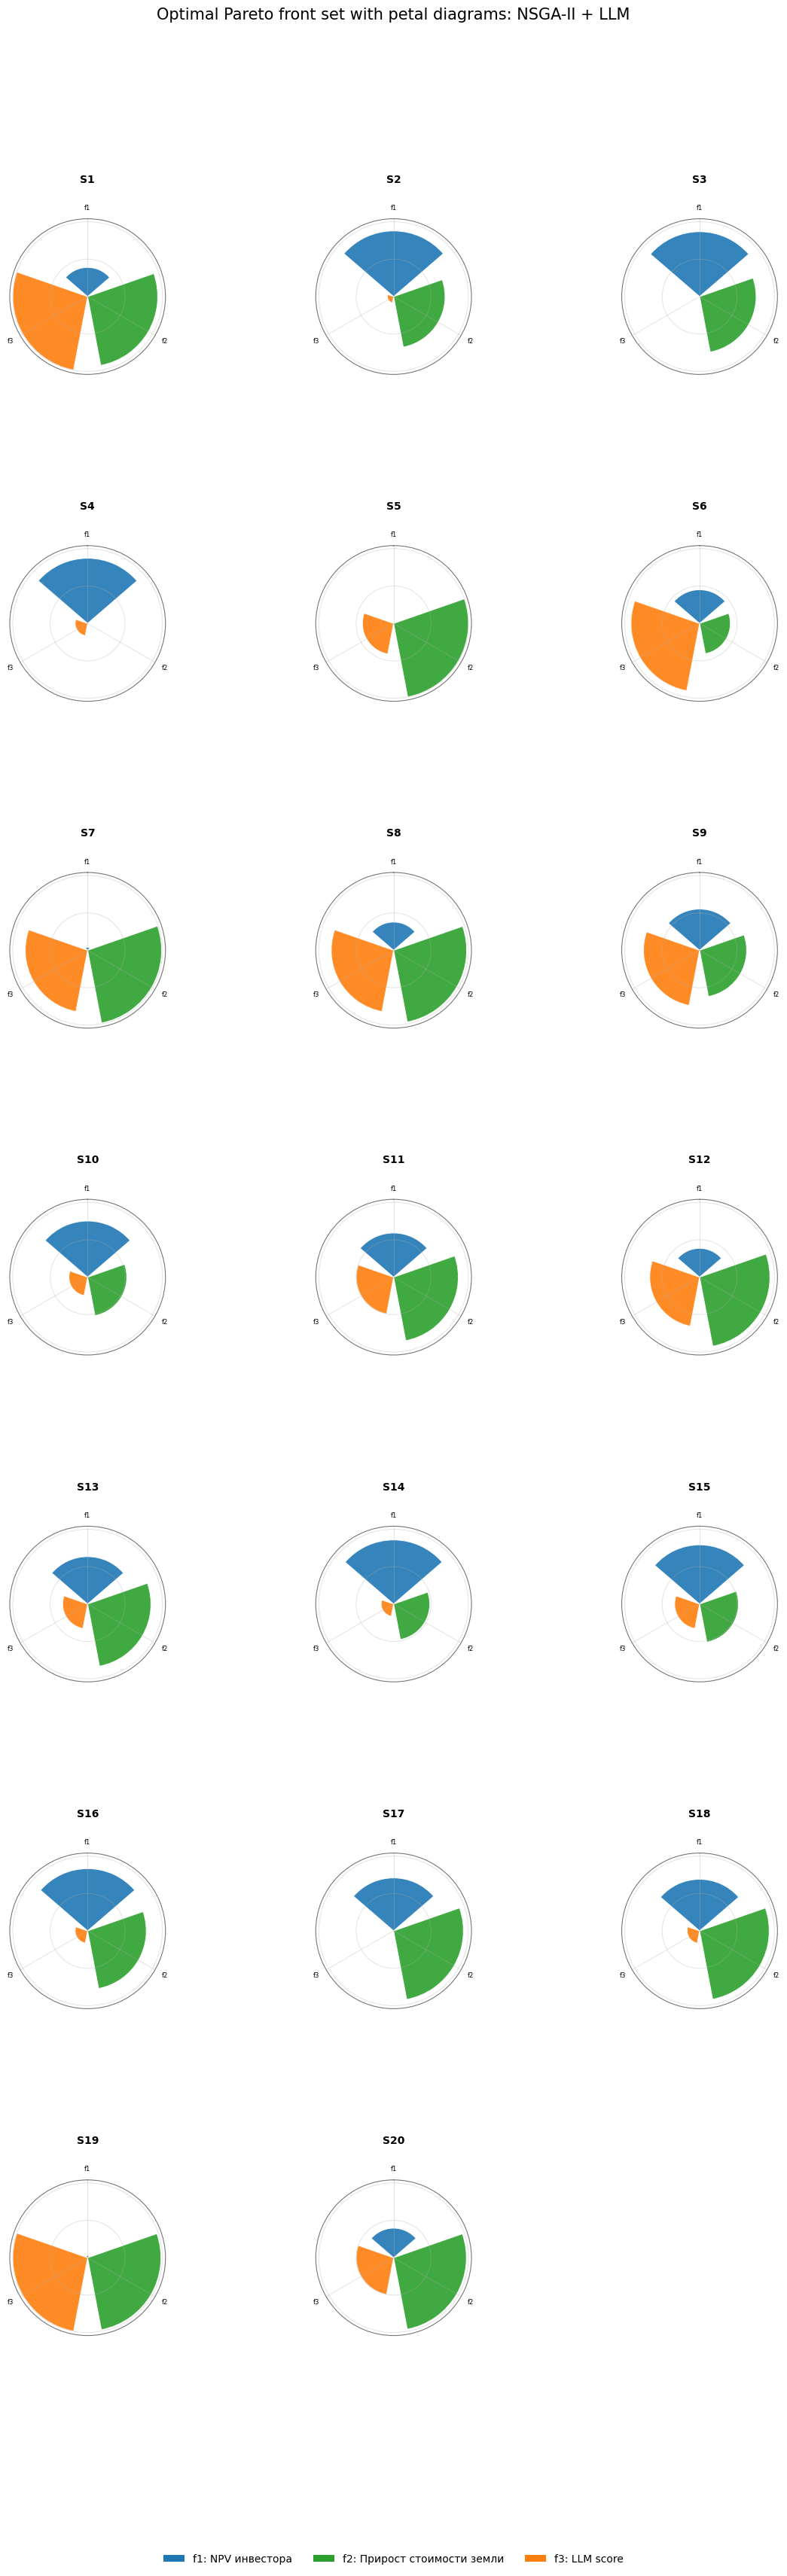

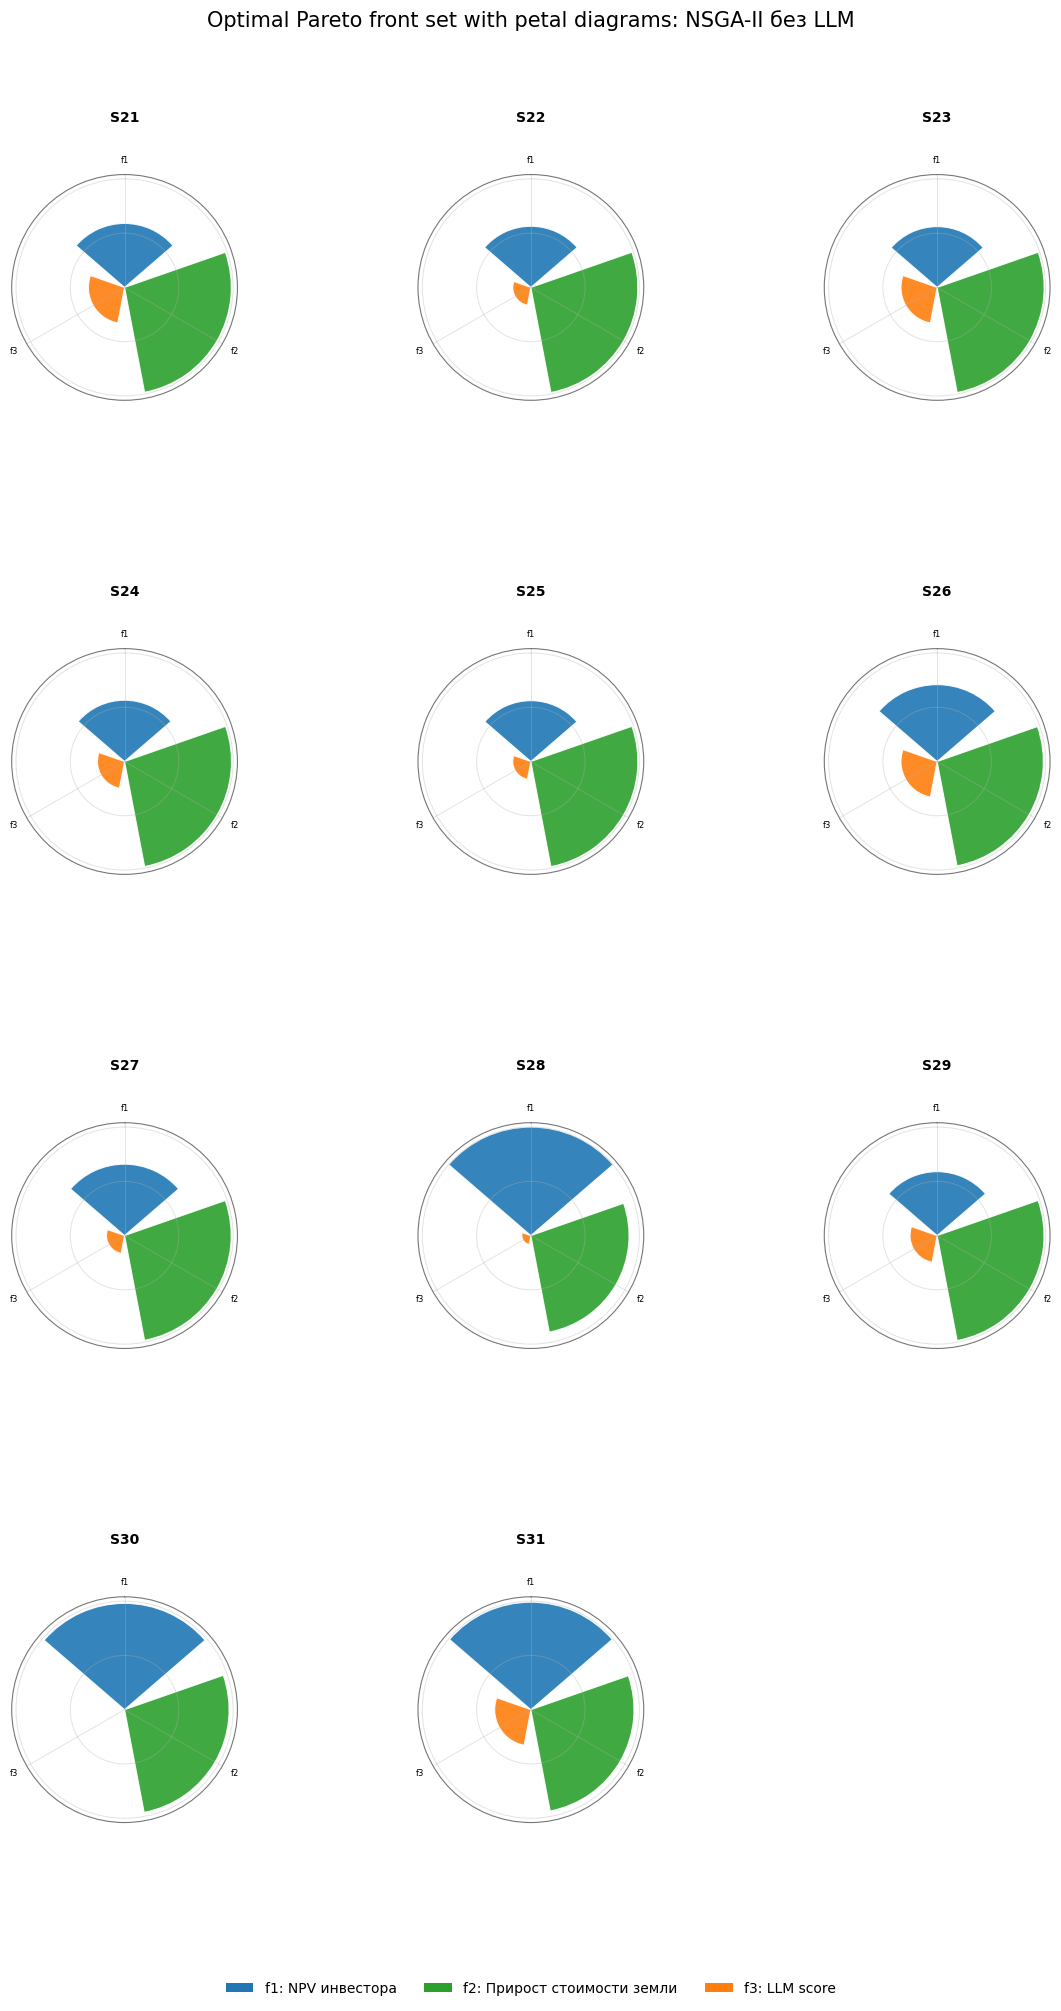

,mean_objective_spread
algorithm,
NSGA-II + LLM,0.289205
NSGA-II без LLM,0.103832


Чем крупнее и разнонаправленнее лепестки внутри одного алгоритма, тем разнообразнее набор решений по целевым критериям.


In [24]:
# Pareto front set with petal diagrams, as in Sicuaio et al. (2024), Figure 13.
from pathlib import Path
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

notebook_dir = Path("examples") if Path("examples/paper.ipynb").exists() else Path(".")
colors = {"NSGA-II + LLM": "#1f9acb", "NSGA-II без LLM": "#8b0015"}

if "fronts_3crit" not in globals():
    llm_3d = pd.read_json(notebook_dir / "pareto_front.jsonl", lines=True)
    no_llm_3d = pd.read_json(notebook_dir / "no_llm_pareto_front_scored.jsonl", lines=True)

    llm_3d["algorithm"] = "NSGA-II + LLM"
    no_llm_3d["algorithm"] = "NSGA-II без LLM"

    for df in (llm_3d, no_llm_3d):
        df["llm_score"] = pd.to_numeric(df.get("llm score"), errors="coerce")
        df["investor_npv"] = pd.to_numeric(df["investor_npv"], errors="coerce")
        df["land_value_gain"] = pd.to_numeric(df["land_value_gain"], errors="coerce")

    fronts_3crit = pd.concat([llm_3d, no_llm_3d], ignore_index=True).dropna(
        subset=["investor_npv", "land_value_gain", "llm_score"]
    )

objective_specs = [
    ("f1", "investor_npv", "NPV инвестора"),
    ("f2", "land_value_gain", "Прирост стоимости земли"),
    ("f3", "llm_score", "LLM score"),
]
objective_cols = [col for _, col, _ in objective_specs]

petal_df = fronts_3crit[["algorithm", "scenario_id", *objective_cols]].copy()
for col in objective_cols:
    petal_df[col] = pd.to_numeric(petal_df[col], errors="coerce")
petal_df = petal_df.dropna(subset=objective_cols).reset_index(drop=True)

mins = petal_df[objective_cols].min()
ranges = (petal_df[objective_cols].max() - mins).replace(0, np.nan)
petal_norm = ((petal_df[objective_cols] - mins) / ranges).fillna(0.0)
petal_norm = petal_norm.clip(0, 1)

petal_scores = petal_df[["algorithm", "scenario_id"]].join(
    petal_norm.rename(columns={col: label for label, col, _ in objective_specs})
)
petal_scores.insert(2, "S", [f"S{i + 1}" for i in range(len(petal_scores))])
display(petal_scores)

objective_colors = {
    "f1": "#1f77b4",
    "f2": "#2ca02c",
    "f3": "#ff7f0e",
}
legend_handles = [
    Patch(facecolor=objective_colors[label], label=f"{label}: {name}")
    for label, _, name in objective_specs
]


def draw_petal(ax, values):
    n = len(values)
    theta = np.linspace(0, 2 * np.pi, n, endpoint=False)
    width = 2 * np.pi / n * 0.82
    labels = [label for label, _, _ in objective_specs]

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.bar(
        theta,
        values,
        width=width,
        bottom=0,
        color=[objective_colors[label] for label in labels],
        edgecolor="white",
        linewidth=0.8,
        alpha=0.9,
    )
    ax.set_ylim(0, 1.04)
    ax.set_xticks(theta)
    ax.set_xticklabels(labels, fontsize=6)
    ax.tick_params(axis="x", pad=0)
    ax.set_yticks([0.5, 1.0])
    ax.set_yticklabels([])
    ax.grid(True, alpha=0.35, linewidth=0.7)
    ax.spines["polar"].set_color("#777777")
    ax.spines["polar"].set_linewidth(0.8)


for algorithm, group in petal_scores.groupby("algorithm", sort=False):
    group = group.reset_index(drop=True)
    n = len(group)
    ncols = min(3, n)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(4.1 * ncols, 4.85 * nrows + 1.2),
        subplot_kw={"projection": "polar"},
    )
    axes = np.atleast_1d(axes).ravel()

    for ax, (_, row) in zip(axes, group.iterrows()):
        draw_petal(ax, row[[label for label, _, _ in objective_specs]].to_numpy(float))
        ax.text(0.5, 1.22, row["S"], transform=ax.transAxes, ha="center", va="bottom", fontsize=10, fontweight="bold")

    for ax in axes[n:]:
        ax.set_visible(False)

    fig.suptitle(f"Optimal Pareto front set with petal diagrams: {algorithm}", fontsize=15, y=0.98)
    fig.legend(
        handles=legend_handles,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.01),
        ncol=len(legend_handles),
        frameon=False,
    )
    fig.subplots_adjust(left=0.05, right=0.95, top=0.90, bottom=0.10, hspace=1.10, wspace=0.38)
    plt.show()

spread_by_objective = (
    petal_scores.groupby("algorithm")[[label for label, _, _ in objective_specs]]
    .std(ddof=0)
    .mean(axis=1)
    .rename("mean_objective_spread")
    .sort_values(ascending=False)
)
display(spread_by_objective.to_frame())
print(
    "Чем крупнее и разнонаправленнее лепестки внутри одного алгоритма, "
    "тем разнообразнее набор решений по целевым критериям."
)


# Визуализация

In [22]:
import tempfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from matplotlib.figure import Figure

from urbanomy.methods.land_value_modeling import (
    ScenarioTEPModifier,
    LandPriceEstimator,
    plot_scenario_impact,
)

FPS = 24

log_path = notebook_dir / "optimization_log.jsonl"
gif_path = notebook_dir / "optimization_log_land_value.gif"

solutions = (
    pd.read_json(log_path, lines=True)
    .dropna(subset=["land_value_gain"])
    .sort_values("land_value_gain")  # от худшего прироста к лучшему
    .reset_index(drop=True)
)

blocks_before = problem.blocks.copy()
blocks_before["is_project"] = blocks_before["id"].eq(target_id)

estimator_kwargs = dict(
    model=problem.model,
    orig_features=problem.estimator_kwargs["orig_features"],
    categorical_features=problem.estimator_kwargs["categorical_features"],
    use_service_features=False,
)

blocks_before_pred = LandPriceEstimator(
    blocks=blocks_before,
    **estimator_kwargs,
).predict()

baseline_cols = blocks_before_pred[["id", "land_value", "site_area"]].copy()
baseline_cols["land_value_before_per_100m2"] = np.where(
    pd.to_numeric(baseline_cols["site_area"], errors="coerce") > 0,
    pd.to_numeric(baseline_cols["land_value"], errors="coerce")
    / pd.to_numeric(baseline_cols["site_area"], errors="coerce") * 100,
    np.nan,
)

baseline_cols = baseline_cols.rename(
    columns={"land_value": "land_value_before"}
)[["id", "land_value_before", "land_value_before_per_100m2"]]

modifier = ScenarioTEPModifier(blocks_before)


def make_frame(row, frame_number, frame_path):
    blocks_after = modifier.apply(target_id, row["params_repaired"])
    blocks_after["is_project"] = blocks_after["id"].eq(target_id)

    blocks_after_pred = LandPriceEstimator(
        blocks=blocks_after,
        **estimator_kwargs,
    ).predict()

    blocks_after_pred["land_value_per_100m2"] = np.where(
        pd.to_numeric(blocks_after_pred["site_area"], errors="coerce") > 0,
        pd.to_numeric(blocks_after_pred["land_value"], errors="coerce")
        / pd.to_numeric(blocks_after_pred["site_area"], errors="coerce") * 100,
        np.nan,
    )

    blocks_full_value = blocks_after_pred.merge(
        baseline_cols,
        on="id",
        how="left",
        validate="one_to_one",
    )

    blocks_full_value["d_rub"] = (
        blocks_full_value["land_value"] - blocks_full_value["land_value_before"]
    )

    blocks_full_value["land_value_delta_pct"] = np.where(
        pd.to_numeric(blocks_full_value["land_value_before"], errors="coerce") > 0,
        (blocks_full_value["land_value"] / blocks_full_value["land_value_before"] - 1) * 100,
        np.nan,
    )

    blocks_full_value = blocks_full_value.replace([np.inf, -np.inf], np.nan)

    result = plot_scenario_impact(
        blocks=blocks_full_value,
        target_idx=target_id,
        target_id_column="id",
        print_summary=False,
        print_quarter_stats=False,
        show=False,
        figsize=(10, 14),
    )

    fig = next(v for v in result.values() if isinstance(v, Figure))
    ax = fig.axes[0]

    for text in list(ax.texts):
        text.remove()

    ax.set_title(
        f"#{frame_number} | прирост: {row['land_value_gain']:,.0f} ₽".replace(",", " "),
        fontsize=11,
        pad=6,
    )
    ax.set_position([0.02, 0.02, 0.88, 0.92])

    legend = ax.get_legend()
    if legend:
        legend.set_title("Обозначения", prop={"size": 8})
        for text in legend.get_texts():
            text.set_fontsize(7)

    fig.savefig(frame_path, dpi=90, bbox_inches="tight", pad_inches=0.15)
    plt.close(fig)


with tempfile.TemporaryDirectory() as tmp:
    frame_paths = []

    for i, row in solutions.iterrows():
        frame_path = Path(tmp) / f"{i:04d}.png"
        make_frame(row, i + 1, frame_path)
        frame_paths.append(frame_path)

        if (i + 1) % 24 == 0:
            print(f"Готово кадров: {i + 1}/{len(solutions)}")

    first = Image.open(frame_paths[0]).convert("P", palette=Image.Palette.ADAPTIVE)
    frames = [
        Image.open(path).convert("P", palette=Image.Palette.ADAPTIVE)
        for path in frame_paths[1:]
    ]

    first.save(
        gif_path,
        save_all=True,
        append_images=frames,
        duration=1000 / FPS,
        loop=0,
        optimize=False,
    )

gif_path


NameError: name 'problem' is not defined

In [37]:
idx = np.argmin(res.F[:, 0])   # максимум land_value

params_optimal = {p: res.X[idx][i] for i, p in enumerate(problem.constraints.keys())}
params_repaired = problem._repair_genome(params_optimal)

metrics = {
    "params_repaired": params_repaired,
    "land_value_after": float(-res.F[idx, 0]),
    "land_value_gain": float(-res.F[idx, 0] - baseline_land_value),
    "investor_npv": float(-res.F[idx, 1]),
}
metrics

{'params_repaired': {'footprint_area': 26066.144054081913,
  'l': 9.969425721056295,
  'mxi': 0.09049475540035413,
  'residential': 0.11311844425044265,
  'business': 0.11928850507167653,
  'recreation': 0.44852853911896445,
  'industrial': 0.16527488754274927,
  'transport': 0.1459260713710682,
  'special': 0.007474887693812074,
  'agriculture': 0.0003886649512869016,
  'share': 0.11311844425044265,
  'land_use': <LandUse.RECREATION: 'recreation'>,
  'build_floor_area': 259864.48698152282,
  'living_area': 23516.37318663142,
  'non_living_area': 236348.1137948914,
  'population': 1175.8186593315709,
  'fsi': 0.9908999661374243,
  'gsi': 0.09939388625410563,
  'morphotype': 'high-rise non-residential'},
 'land_value_after': 63803022547.9684,
 'land_value_gain': 851502634.2794647,
 'investor_npv': 2873384770.15}

Изменение стоимости земли по всем кварталам:
 • Сумма до:    62 951 519 914 ₽
 • Сумма после: 63 803 022 548 ₽
 • Изм.  ₽:     +851 502 634 ₽
 • Изм., %:     +1.35%

Изменяемый квартал:
 • До: 590 959 314 ₽ | После: 675 947 232 ₽ | Δ: +84 987 918 ₽ | Δ%: +14.38%


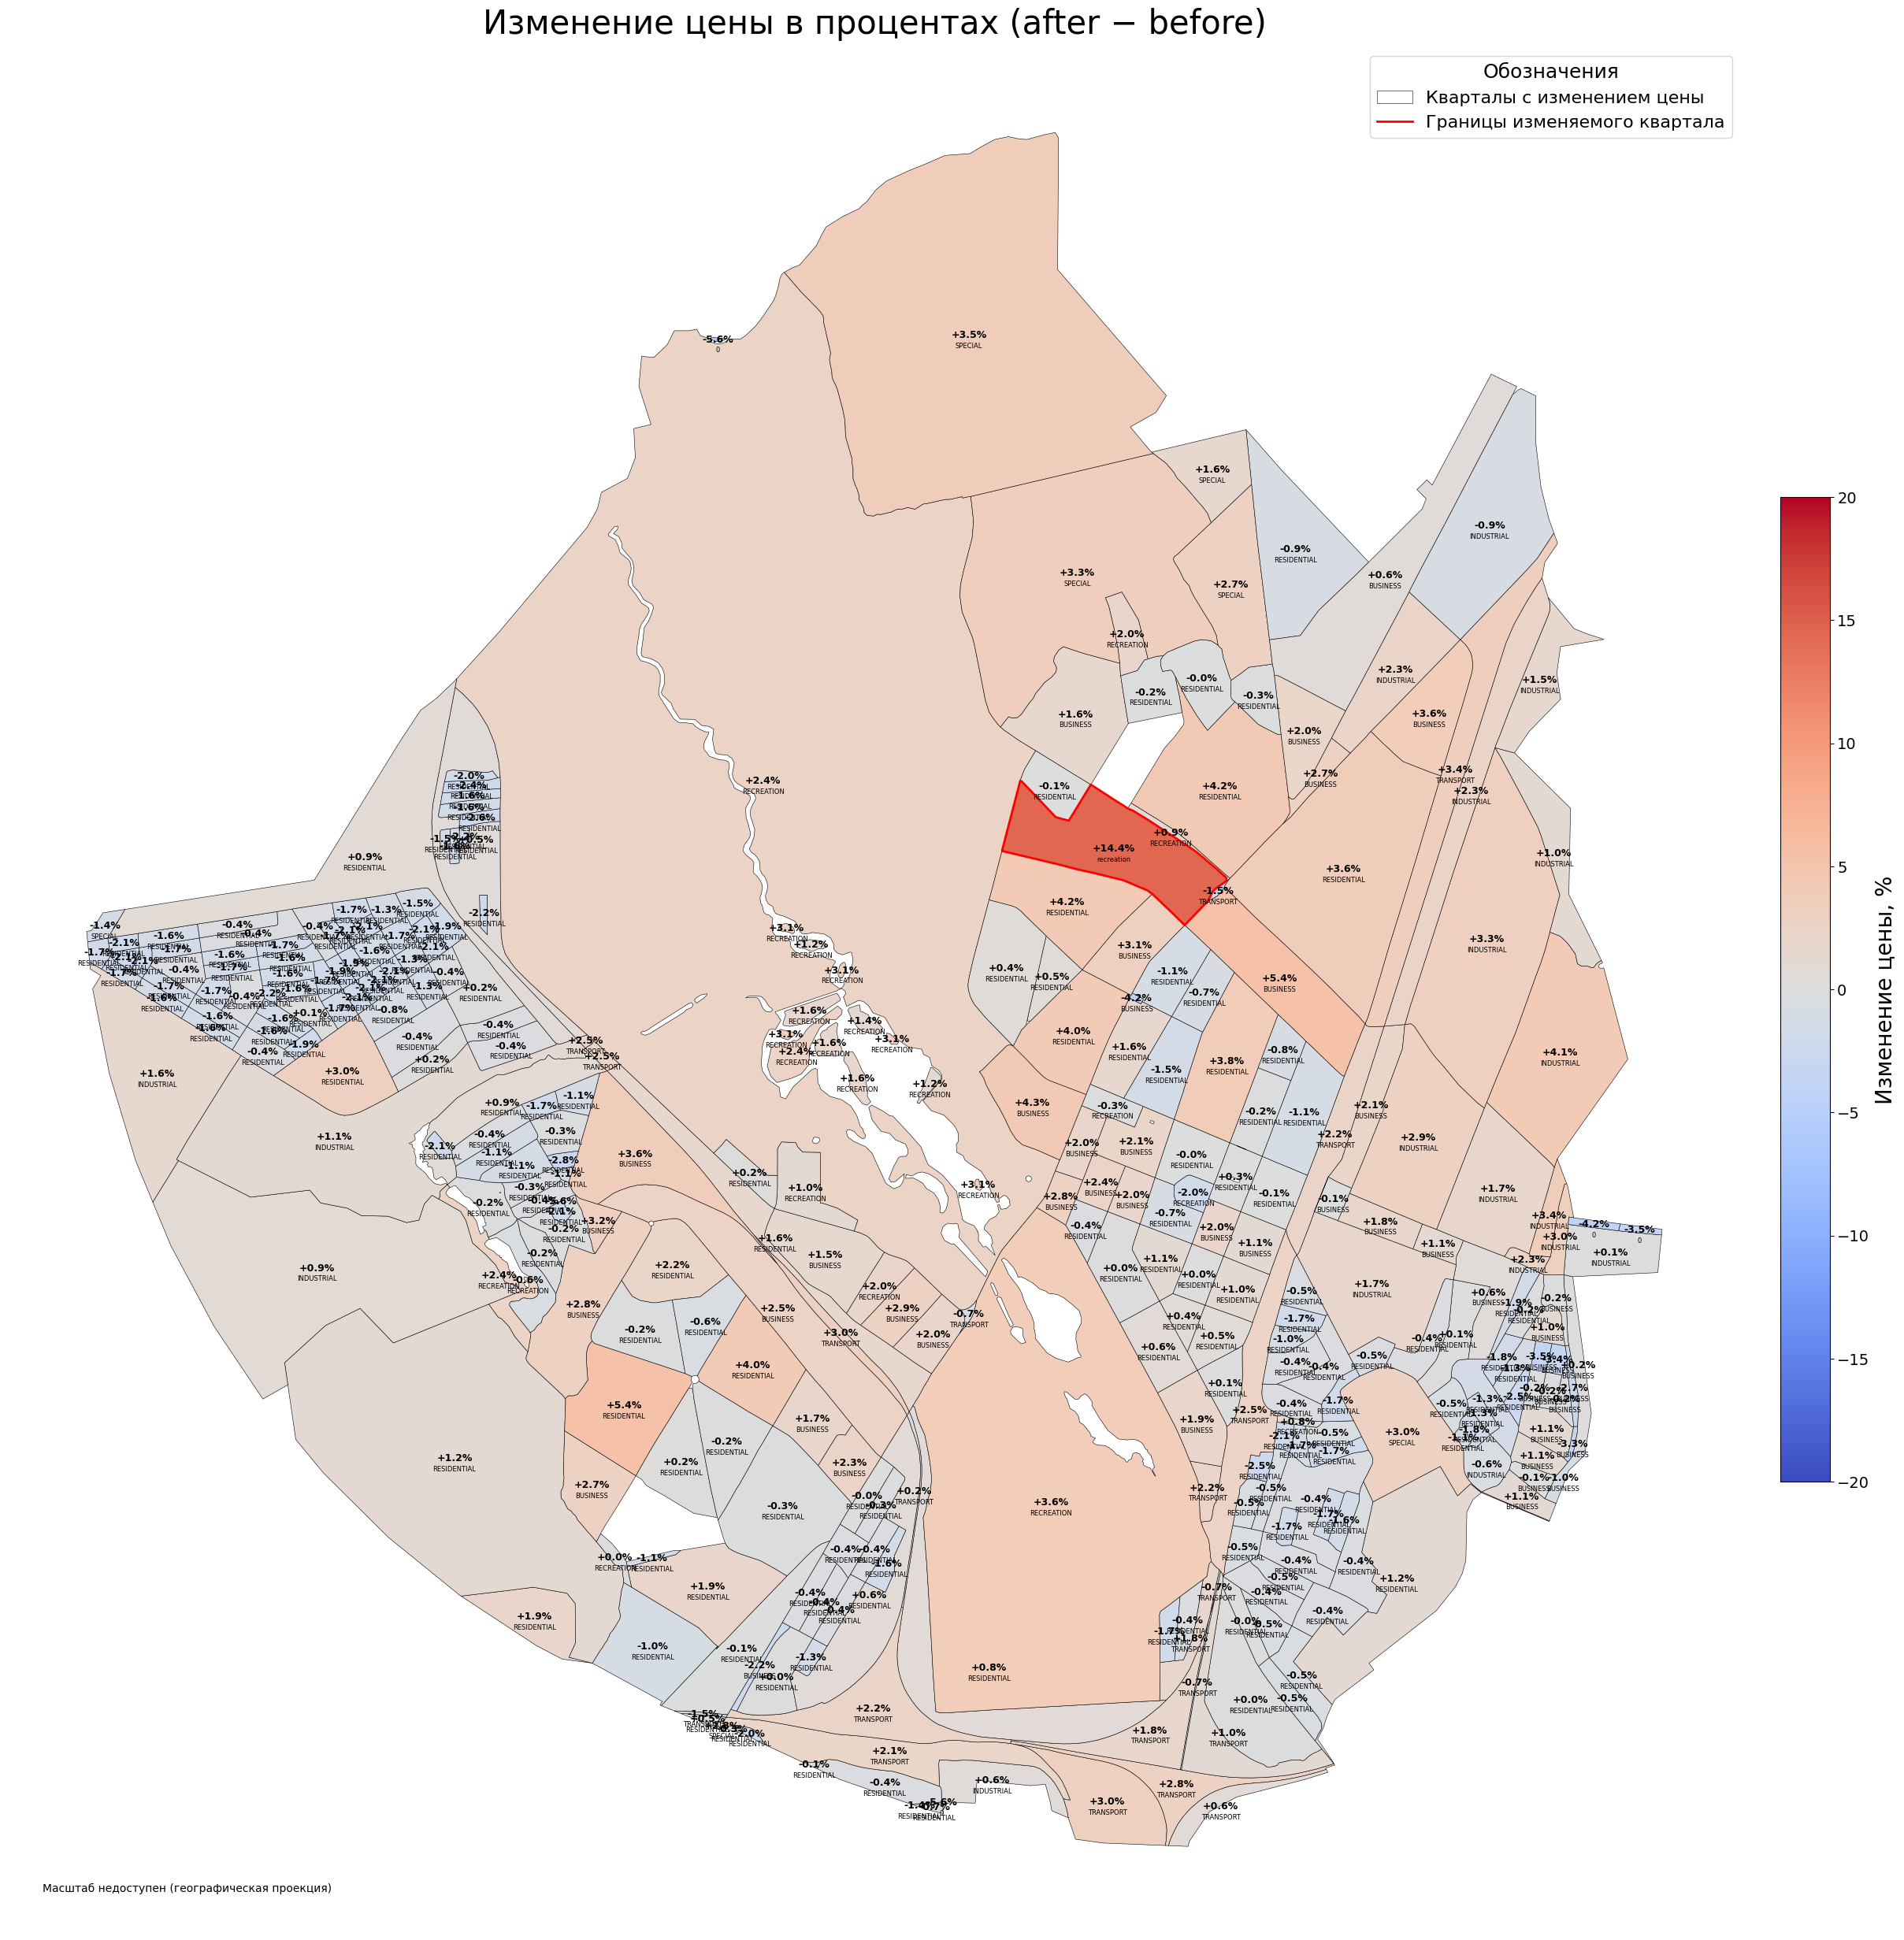

In [38]:
import numpy as np
import pandas as pd

from urbanomy.methods.land_value_modeling import (
    ScenarioTEPModifier,
    LandPriceEstimator,
    plot_scenario_impact,
)


# Базовые кварталы должны быть теми же, что использовал оптимизатор
blocks_before = problem.blocks.copy()

# Помечаем проектный квартал
blocks_before["is_project"] = False
blocks_before.loc[blocks_before["id"] == target_id, "is_project"] = True

# 1) Применяем оптимизационный сценарий к базовым кварталам
modifier = ScenarioTEPModifier(blocks_before)
blocks_after = modifier.apply(target_id, params_repaired)
blocks_after["is_project"] = False
blocks_after.loc[blocks_after["id"] == target_id, "is_project"] = True

# 2) Считаем стоимость "до" и "после" тем же способом, что и в DistrictProblem
estimator_kwargs = dict(
    model=problem.model,
    orig_features=problem.estimator_kwargs["orig_features"],
    categorical_features=problem.estimator_kwargs["categorical_features"],
    use_service_features=False,
)

baseline_estimator = LandPriceEstimator(
    blocks=blocks_before,
    **estimator_kwargs,
)
blocks_before_pred = baseline_estimator.predict()

scenario_estimator = LandPriceEstimator(
    blocks=blocks_after,
    **estimator_kwargs,
)
blocks_after_pred = scenario_estimator.predict()

for df in (blocks_before_pred, blocks_after_pred):
    df["land_value_per_100m2"] = np.where(
        pd.to_numeric(df["site_area"], errors="coerce") > 0,
        pd.to_numeric(df["land_value"], errors="coerce")
        / pd.to_numeric(df["site_area"], errors="coerce") * 100,
        np.nan,
    )

baseline_cols = blocks_before_pred[
    ["id", "land_value", "land_value_per_100m2"]
].rename(
    columns={
        "land_value": "land_value_before",
        "land_value_per_100m2": "land_value_before_per_100m2",
    }
)

blocks_full_value = blocks_after_pred.merge(
    baseline_cols,
    on="id",
    how="left",
    validate="one_to_one",
)

blocks_full_value["d_rub"] = (
    blocks_full_value["land_value"] - blocks_full_value["land_value_before"]
)

blocks_full_value["land_value_delta_pct"] = np.where(
    pd.to_numeric(blocks_full_value["land_value_before"], errors="coerce") > 0,
    (blocks_full_value["land_value"] / blocks_full_value["land_value_before"] - 1.0) * 100,
    np.nan,
)

blocks_full_value = blocks_full_value.replace([np.inf, -np.inf], np.nan)

sum_before = float(blocks_full_value["land_value_before"].sum())
sum_after = float(blocks_full_value["land_value"].sum())
sum_delta = sum_after - sum_before
sum_delta_pct = (sum_after / sum_before - 1.0) * 100 if sum_before > 0 else np.nan

print("Изменение стоимости земли по всем кварталам:")
print(f" • Сумма до:    {sum_before:,.0f} ₽".replace(",", " "))
print(f" • Сумма после: {sum_after:,.0f} ₽".replace(",", " "))
print(f" • Изм., ₽:     {sum_delta:+,.0f} ₽".replace(",", " "))
print(f" • Изм., %:     {sum_delta_pct:+.2f}%")

target_row = blocks_full_value.loc[blocks_full_value["id"] == target_id].iloc[0]
print("\nИзменяемый квартал:")
print(
    f" • До: {target_row['land_value_before']:,.0f} ₽ | "
    f"После: {target_row['land_value']:,.0f} ₽ | "
    f"Δ: {target_row['d_rub']:+,.0f} ₽ | "
    f"Δ%: {target_row['land_value_delta_pct']:+.2f}%".replace(",", " ")
)

scenario_result = plot_scenario_impact(
    blocks=blocks_full_value,
    target_idx=target_id,
    target_id_column="id",
    print_summary=False,
    print_quarter_stats=False,
    figsize=(25, 35),
)
